In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
import tensorflow as tf
import joblib
sns.set()
from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import RegressorChain
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

2026-07-03 20:51:53.275992: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783111913.688579      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783111913.786321      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783111914.691331      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783111914.691371      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783111914.691374      58 computation_placer.cc:177] computation placer alr

# Function Helper

In [9]:
def plot_all_data_kuantitatif(df):
    numeric_df = df.select_dtypes(include='number')
    numeric_cols = numeric_df.columns.tolist()
    num_features = len(numeric_cols)
    
    # 3. Menentukan layout grid (baris x kolom)
    # Misalnya kita ingin maksimal 2 kolom ke samping, lalu barisnya menyesuaikan
    cols = 3
    rows = math.ceil(num_features / cols) 
    
    # 4. Membuat kanvas (figure) dan sumbu (axes)
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(19, 4 * rows))
    axes = axes.flatten() 
    
    # 5. Membuat visualisasi untuk setiap kolom numerik
    for i, col in enumerate(numeric_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i])
        
        # Menambahkan judul untuk setiap subplot
        axes[i].set_title(f'Distribusi: {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frekuensi')
    
    # 6. Menyembunyikan subplot yang kosong (jika jumlah kolom ganjil / tidak memenuhi grid)
    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j]) # Menghapus axis yang tidak terpakai
    
    # 7. Menyesuaikan jarak antar plot agar tidak tumpang tindih dan menampilkannya
    plt.tight_layout()
    plt.show()

In [10]:
def plot_all_data_kualitatif(df):
    cat_df = df.select_dtypes(include=['object', 'category'])
    cat_cols = cat_df.columns.tolist()
    num_features = len(cat_cols)
    
    # 3. Menentukan layout grid
    cols = 3
    rows = math.ceil(num_features / cols) 
    
    # 4. Membuat kanvas (figure)
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(19, 4 * rows))
    axes = axes.flatten() 
    
    # 5. Membuat visualisasi dengan warna kustom
    for i, col in enumerate(cat_cols):
        
        # Menghitung frekuensi (jumlah) dari tiap kategori
        counts = df[col].value_counts()
        
        # Mengambil urutan nama kategori dari yang paling sering muncul
        order = counts.index
        
        # Mencari nama kategori dengan nilai tertinggi
        max_category = counts.idxmax()
        
        # Membuat daftar warna: 'royalblue' untuk yang tertinggi, 'lightgray' untuk sisanya
        custom_colors = ['blue' if cat == max_category else 'lightgray' for cat in order]
        
        # Membuat countplot
        # - Parameter 'order' memastikan batang diurutkan dari yang tertinggi
        # - Parameter 'palette' menerima daftar warna yang baru saja kita buat
        sns.countplot(data=df, x=col, ax=axes[i], order=order, palette=custom_colors)
        
        # Menambahkan judul dan label
        axes[i].set_title(f'Frekuensi Kategori: {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Jumlah')
    
    # 6. Menyembunyikan subplot yang kosong
    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])
    
    # 7. Menyesuaikan jarak antar plot dan menampilkan
    plt.tight_layout()
    plt.show()

In [11]:
def plot_distribution_data_kuantitatif(df, feature, title, x_lim=1000, bins=30):
  mean = df[feature].mean()
  median = df[feature].median()
  mode = df[feature].mode()[0]

  plt.figure(figsize=(10, 6))
  sns.histplot(df[feature], bins=bins, kde=True)
  plt.title(title, fontsize=16)
  plt.xlabel(None)
  plt.ylabel(None)

  plt.axvline(mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean:.2f}')
  plt.axvline(median, color='green', linestyle='dashed', linewidth=1, label=f'Median: {median:.2f}')
  plt.axvline(mode, color='purple', linestyle='dashed', linewidth=1, label=f'Mode: {mode:.2f}')

  plt.xlim(0, x_lim)
  plt.grid(axis='y', alpha=0.75)
  plt.legend()
  plt.show()

In [12]:
def plot_frequency_data_kualitatif(df, feature, title, kind="bar", top_10=False, tail=False):
  if top_10:
    if tail:
      plot_data = df[feature].value_counts().tail(10)
      colors = ['blue' if (x == plot_data.min()) else 'lightgray' for x in plot_data]
    else:
      plot_data = df[feature].value_counts().head(10)
      colors = ['blue' if (x == plot_data.max()) else 'lightgray' for x in plot_data]
  else:
    plot_data = df[feature].value_counts()
    colors = ['blue' if (x == plot_data.max()) else 'lightgray' for x in plot_data]

  ax = plot_data.plot.bar(figsize=(15, 5), color=colors) if kind == "bar" else plot_data.plot.barh(figsize=(15, 5), color=colors)
  ax.set_title(title, fontsize=14)
  ax.set_xlabel(None)
  ax.set_ylabel(None)

  for container in ax.containers:
      ax.bar_label(container)

  plt.show()

In [13]:
def plot_sum_grouped_data_kuantitatif(df, features, values, title, kind="bar", top_10=False, tail=False):
  if top_10:
    if tail:
      plot_data = df.groupby(features)[values].sum().sort_values(ascending=False).tail(10)
      colors = ['blue' if (x == plot_data.min()) else 'lightgray' for x in plot_data]
    else:
      plot_data = df.groupby(features)[values].sum().sort_values(ascending=False).head(10)
      colors = ['blue' if (x == plot_data.max()) else 'lightgray' for x in plot_data]
  else:
    plot_data = df.groupby(features)[values].sum().sort_values(ascending=False)
    colors = ['blue' if (x == plot_data.max()) else 'lightgray' for x in plot_data]

  ax = plot_data.plot.bar(figsize=(15, 5), color=colors) if kind == "bar" else plot_data.plot.barh(figsize=(15, 5), color=colors)
  ax.set_title(title, fontsize=14)
  ax.set_xlabel(None)
  ax.set_ylabel(None)

  for container in ax.containers:
      ax.bar_label(container)

  plt.show()

In [14]:
def cek_outlier_boxplot(df):
    # 1. Pilih hanya fitur numerik (int dan float)
    fitur_numerik = df.select_dtypes(include=[np.number]).columns

    if len(fitur_numerik) == 0:
        print("Tidak ditemukan fitur numerik dalam dataset ini.")
        return

    # 2. Atur tata letak (grid) visualisasi agar rapi
    n_kolom = len(fitur_numerik)
    plot_per_baris = 3  # Maksimal 3 boxplot per baris
    n_baris = (n_kolom + plot_per_baris - 1) // plot_per_baris

    plt.figure(figsize=(5 * plot_per_baris, 4 * n_baris))

    # 3. Looping untuk membuat boxplot tiap fitur numerik
    for i, kolom in enumerate(fitur_numerik, 1):
        plt.subplot(n_baris, plot_per_baris, i)
        sns.boxplot(y=df[kolom])
        plt.title(f"{kolom}", fontsize=12)
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

In [15]:
def plot_acf_or_pacf(df, feature, name, max_lags, target_lags=None):
    highlight_color = 'blue'
    plt.figure(figsize=(15, 8))
    ax = plt.gca()
    
    if name == "acf":
        plot_acf(df[feature], lags=max_lags, ax=ax, auto_ylims=True, 
                color='gray', vlines_kwargs={"colors": 'gray'})
        acf_values = acf(df[feature], nlags=max_lags, fft=False, missing='drop')

        if target_lags:
            for lag_idx in target_lags:
                if lag_idx <= max_lags:
                    val = acf_values[lag_idx]
                    plt.vlines(x=lag_idx, ymin=0, ymax=val, colors=highlight_color, linewidth=3, zorder=5)
                    plt.scatter(x=lag_idx, y=val, color=highlight_color, s=100, zorder=6)

        plt.title(f"Autocorrelation Function (ACF) {feature}", fontsize=14)
        plt.xlabel("Lag", fontsize=12)
        plt.ylabel("Autocorrelation", fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()
    else:
        plot_pacf(df[feature], lags=max_lags, ax=ax, auto_ylims=True, 
                color='gray', vlines_kwargs={"colors": 'gray'})
        pacf_values = pacf(df[feature], nlags=max_lags, method='ywm')

        for lag_idx in target_lags:
            if lag_idx <= max_lags:
                val = pacf_values[lag_idx]
                plt.vlines(x=lag_idx, ymin=0, ymax=val, colors=highlight_color, linewidth=3, zorder=5)
                plt.scatter(x=lag_idx, y=val, color=highlight_color, s=100, zorder=6)

        plt.title(f"Partial Autocorrelation (PACF) {feature}", fontsize=14)
        plt.xlabel("Lag", fontsize=12)
        plt.ylabel("Partial Autocorrelation", fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()

# Data Collections

In [16]:
df = pd.read_csv("/kaggle/input/datasets/harrachimustapha/maintenance-machine/sensor_data.csv")
df

,timestamp,machine_id,temperature_C,vibration_mm_s,pressure_bar,status,operating_hours,ambient_temp_C,shift,production_count,defect_count,good_count
0,01/01/2024 00:00,M001,15.32,0.014,0.02,STOPPED,0.00,15.0,Night_Break,0,0,0
1,01/01/2024 00:05,M001,15.30,0.007,0.00,STOPPED,0.00,15.0,Night_Break,0,0,0
2,01/01/2024 00:10,M001,14.69,0.010,0.04,STOPPED,0.00,15.0,Night_Break,0,0,0
3,01/01/2024 00:15,M001,15.47,0.008,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
4,01/01/2024 00:20,M001,14.90,0.029,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
421627,31/12/2024 23:35,M004,82.06,5.797,4.41,RUNNING,4002.56,15.0,Evening_Shift,5,0,5
421628,31/12/2024 23:40,M004,80.58,6.404,4.34,RUNNING,4002.64,15.0,Evening_Shift,6,1,5
421629,31/12/2024 23:45,M004,82.14,6.201,4.42,RUNNING,4002.72,15.0,Evening_Shift,6,2,4
421630,31/12/2024 23:50,M004,79.54,6.505,4.32,RUNNING,4002.80,15.0,Evening_Shift,7,2,5


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421632 entries, 0 to 421631
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   timestamp         421632 non-null  object 
 1   machine_id        421632 non-null  object 
 2   temperature_C     421632 non-null  float64
 3   vibration_mm_s    421632 non-null  float64
 4   pressure_bar      421632 non-null  float64
 5   status            421632 non-null  object 
 6   operating_hours   421632 non-null  float64
 7   ambient_temp_C    421632 non-null  float64
 8   shift             421632 non-null  object 
 9   production_count  421632 non-null  int64  
 10  defect_count      421632 non-null  int64  
 11  good_count        421632 non-null  int64  
dtypes: float64(5), int64(3), object(4)
memory usage: 38.6+ MB


In [18]:
df

,timestamp,machine_id,temperature_C,vibration_mm_s,pressure_bar,status,operating_hours,ambient_temp_C,shift,production_count,defect_count,good_count
0,01/01/2024 00:00,M001,15.32,0.014,0.02,STOPPED,0.00,15.0,Night_Break,0,0,0
1,01/01/2024 00:05,M001,15.30,0.007,0.00,STOPPED,0.00,15.0,Night_Break,0,0,0
2,01/01/2024 00:10,M001,14.69,0.010,0.04,STOPPED,0.00,15.0,Night_Break,0,0,0
3,01/01/2024 00:15,M001,15.47,0.008,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
4,01/01/2024 00:20,M001,14.90,0.029,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
421627,31/12/2024 23:35,M004,82.06,5.797,4.41,RUNNING,4002.56,15.0,Evening_Shift,5,0,5
421628,31/12/2024 23:40,M004,80.58,6.404,4.34,RUNNING,4002.64,15.0,Evening_Shift,6,1,5
421629,31/12/2024 23:45,M004,82.14,6.201,4.42,RUNNING,4002.72,15.0,Evening_Shift,6,2,4
421630,31/12/2024 23:50,M004,79.54,6.505,4.32,RUNNING,4002.80,15.0,Evening_Shift,7,2,5


In [19]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
df.set_index('timestamp', inplace=True)
df

,machine_id,temperature_C,vibration_mm_s,pressure_bar,status,operating_hours,ambient_temp_C,shift,production_count,defect_count,good_count
timestamp,,,,,,,,,,,
2024-01-01 00:00:00,M001,15.32,0.014,0.02,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:05:00,M001,15.30,0.007,0.00,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:10:00,M001,14.69,0.010,0.04,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:15:00,M001,15.47,0.008,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:20:00,M001,14.90,0.029,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 23:35:00,M004,82.06,5.797,4.41,RUNNING,4002.56,15.0,Evening_Shift,5,0,5
2024-12-31 23:40:00,M004,80.58,6.404,4.34,RUNNING,4002.64,15.0,Evening_Shift,6,1,5
2024-12-31 23:45:00,M004,82.14,6.201,4.42,RUNNING,4002.72,15.0,Evening_Shift,6,2,4


In [20]:
df.describe()

,temperature_C,vibration_mm_s,pressure_bar,operating_hours,ambient_temp_C,production_count,defect_count,good_count
count,421632.000000,421632.000000,421632.000000,421632.000000,421632.000000,421632.000000,421632.000000,421632.000000
mean,46.559409,2.072873,2.328687,2008.290886,20.189451,3.190702,0.335174,2.855528
std,28.627852,2.269268,2.418014,1154.450648,3.826584,3.407399,0.696318,3.143624
min,14.500000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000
25%,19.040000,0.014000,0.020000,996.860000,16.900000,0.000000,0.000000,0.000000
50%,26.340000,0.029000,0.050000,2000.560000,20.000000,0.000000,0.000000,0.000000
75%,75.760000,4.156000,4.830000,3004.960000,23.100000,7.000000,0.000000,6.000000
max,97.840000,14.818000,6.570000,4018.720000,29.100000,9.000000,6.000000,9.000000


In [21]:
print(f"Jumlah data duplikat: {df.duplicated().sum()} data")

Jumlah data duplikat: 175 data


# Exploratory Data Analysis

In [22]:
df.drop_duplicates(inplace=True)
print(f"Jumlah data duplikat: {df.duplicated().sum()} data")
df

Jumlah data duplikat: 0 data


,machine_id,temperature_C,vibration_mm_s,pressure_bar,status,operating_hours,ambient_temp_C,shift,production_count,defect_count,good_count
timestamp,,,,,,,,,,,
2024-01-01 00:00:00,M001,15.32,0.014,0.02,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:05:00,M001,15.30,0.007,0.00,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:10:00,M001,14.69,0.010,0.04,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:15:00,M001,15.47,0.008,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:20:00,M001,14.90,0.029,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 23:35:00,M004,82.06,5.797,4.41,RUNNING,4002.56,15.0,Evening_Shift,5,0,5
2024-12-31 23:40:00,M004,80.58,6.404,4.34,RUNNING,4002.64,15.0,Evening_Shift,6,1,5
2024-12-31 23:45:00,M004,82.14,6.201,4.42,RUNNING,4002.72,15.0,Evening_Shift,6,2,4


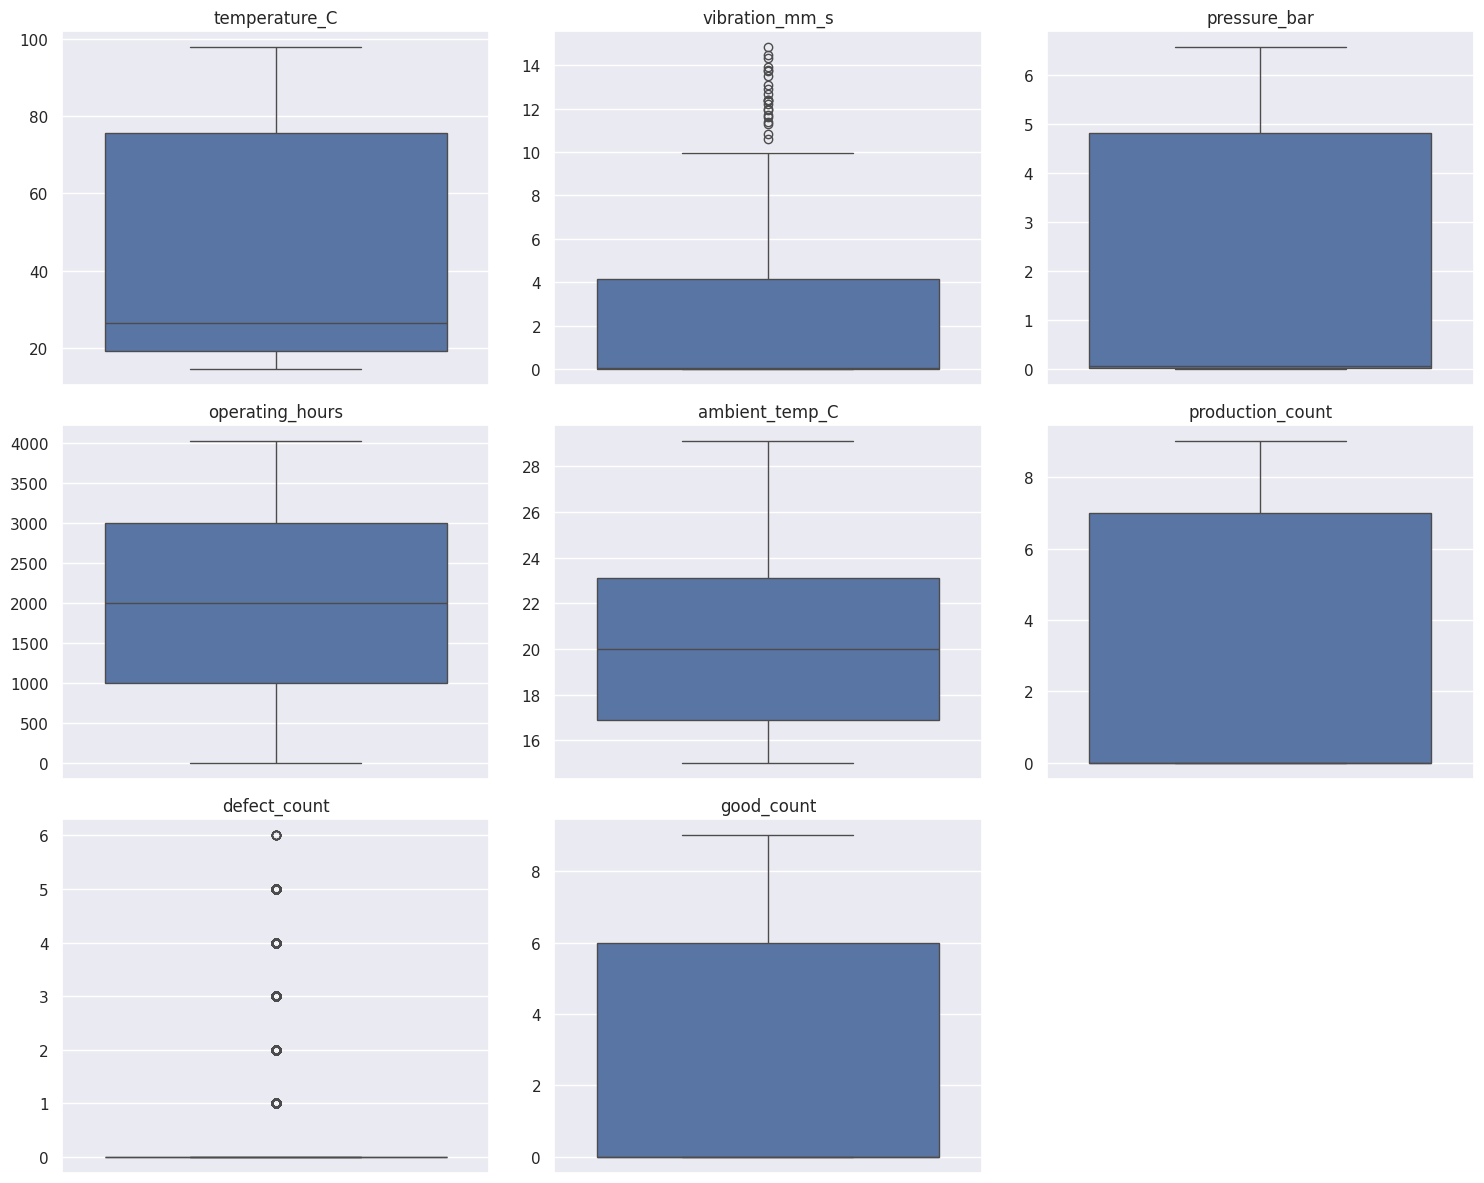

In [23]:
cek_outlier_boxplot(df)

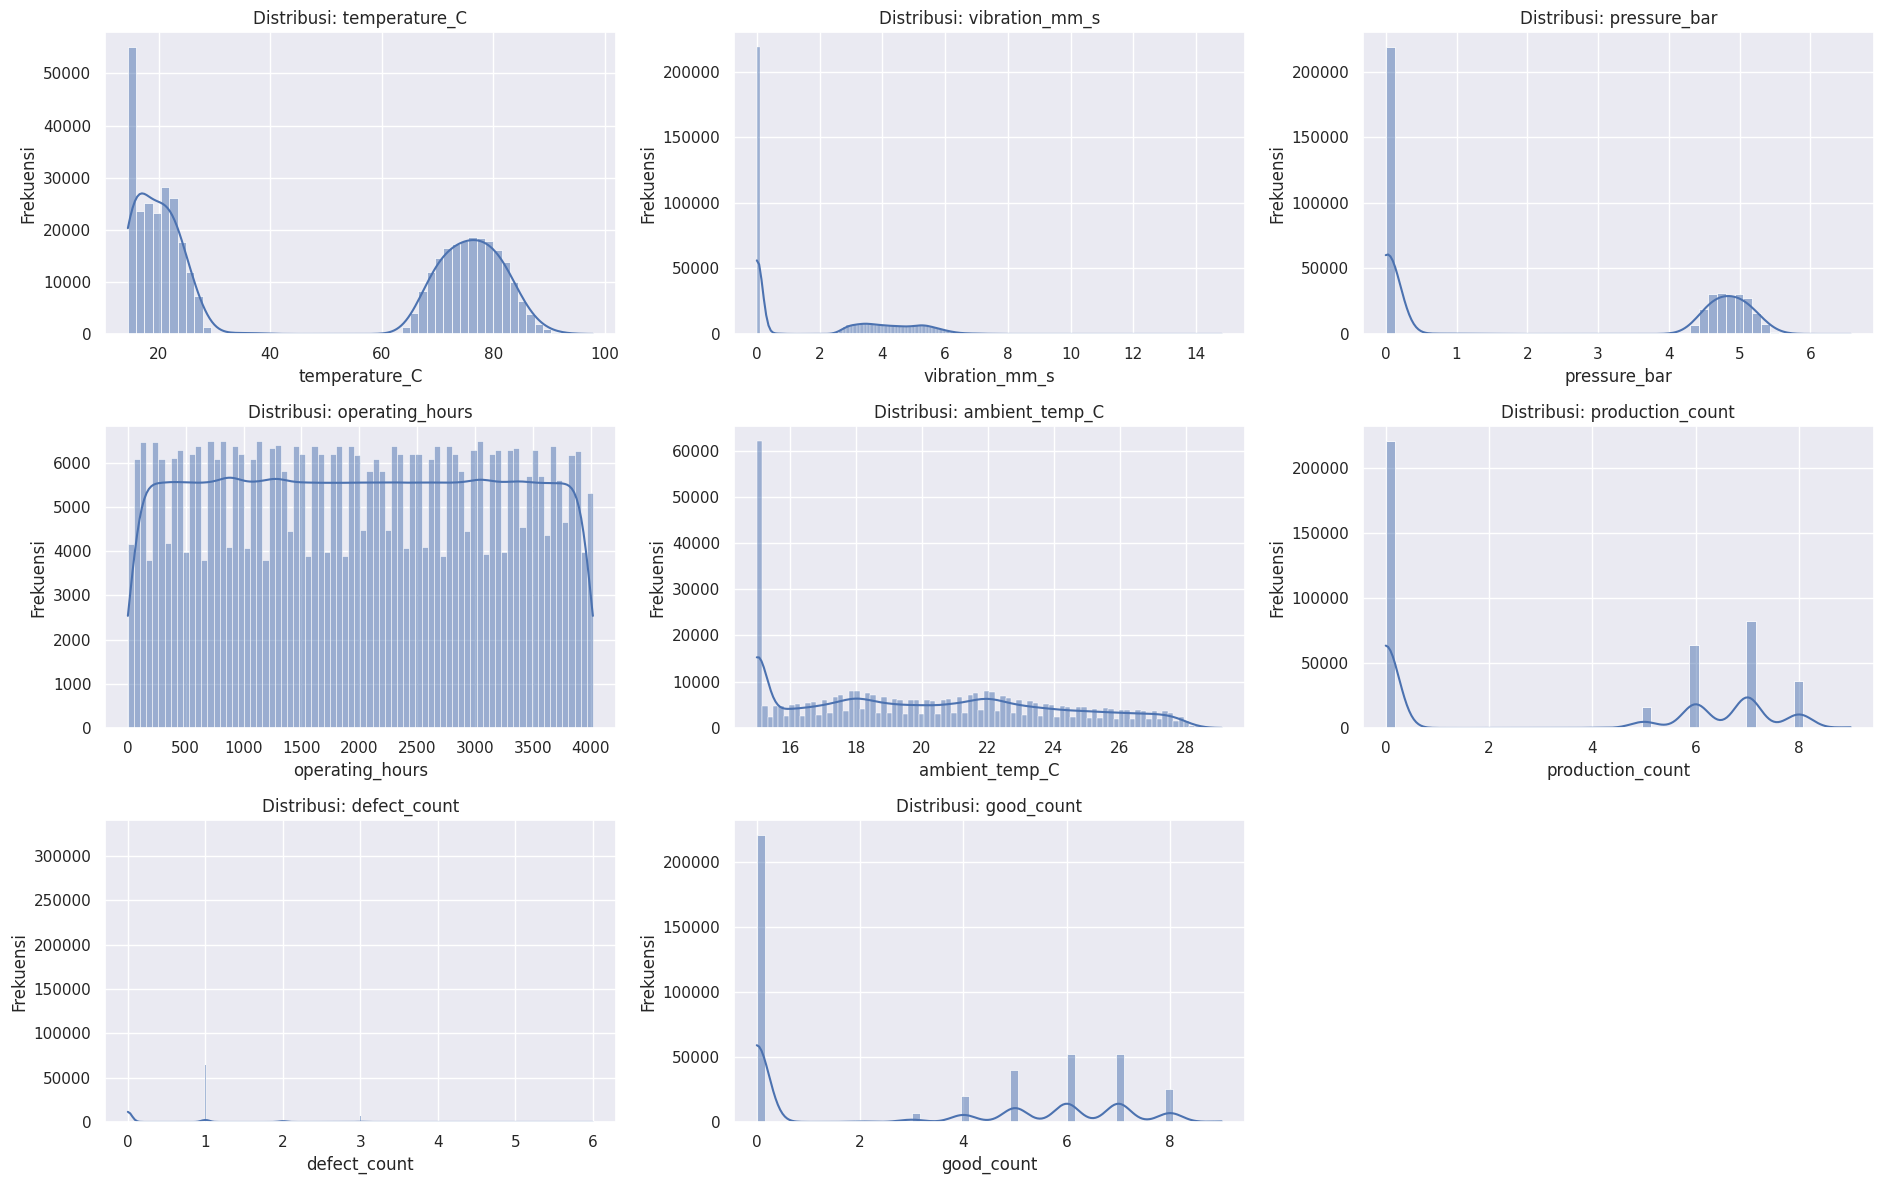

In [24]:
plot_all_data_kuantitatif(df)

/tmp/ipykernel_58/2600073128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=order, palette=custom_colors)
/tmp/ipykernel_58/2600073128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=order, palette=custom_colors)
/tmp/ipykernel_58/2600073128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=order, palette=custom_colors)


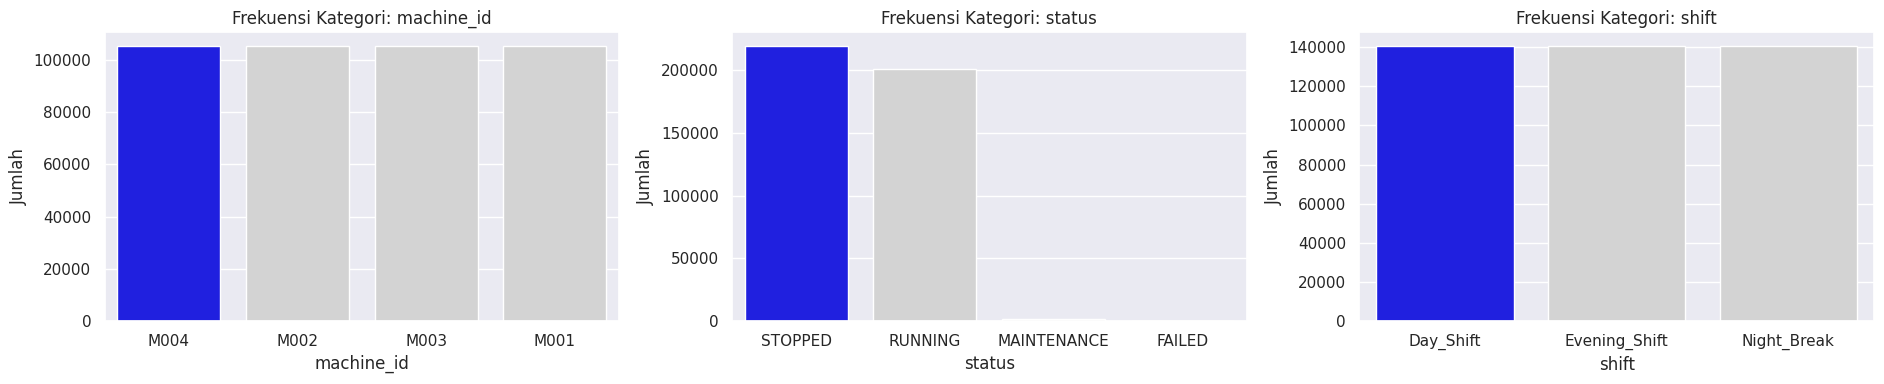

In [25]:
plot_all_data_kualitatif(df)

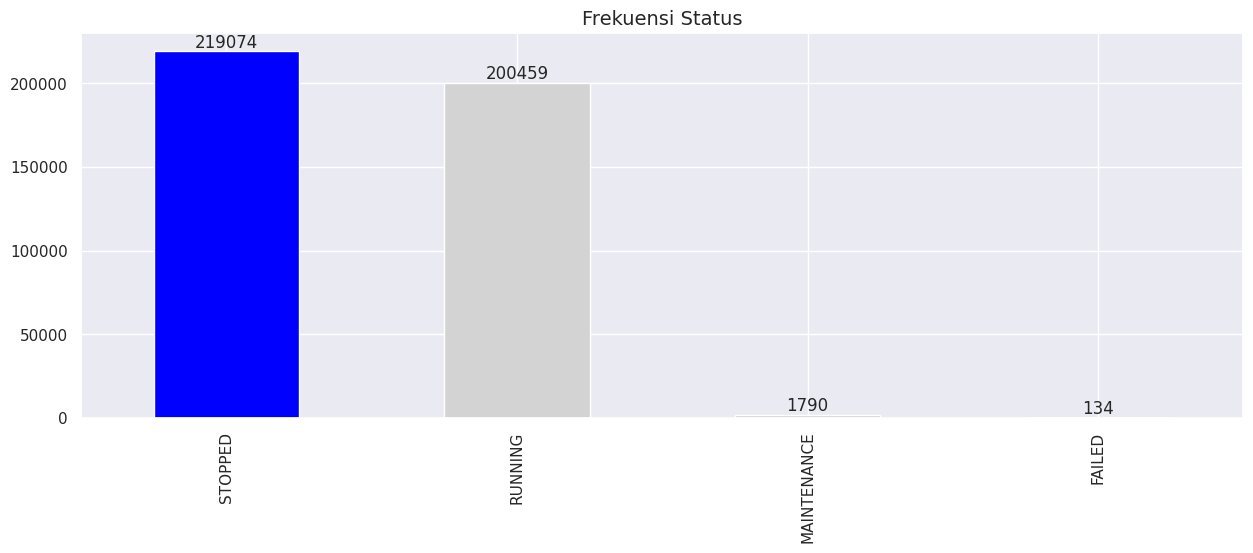

In [26]:
plot_frequency_data_kualitatif(df, "status", "Frekuensi Status")

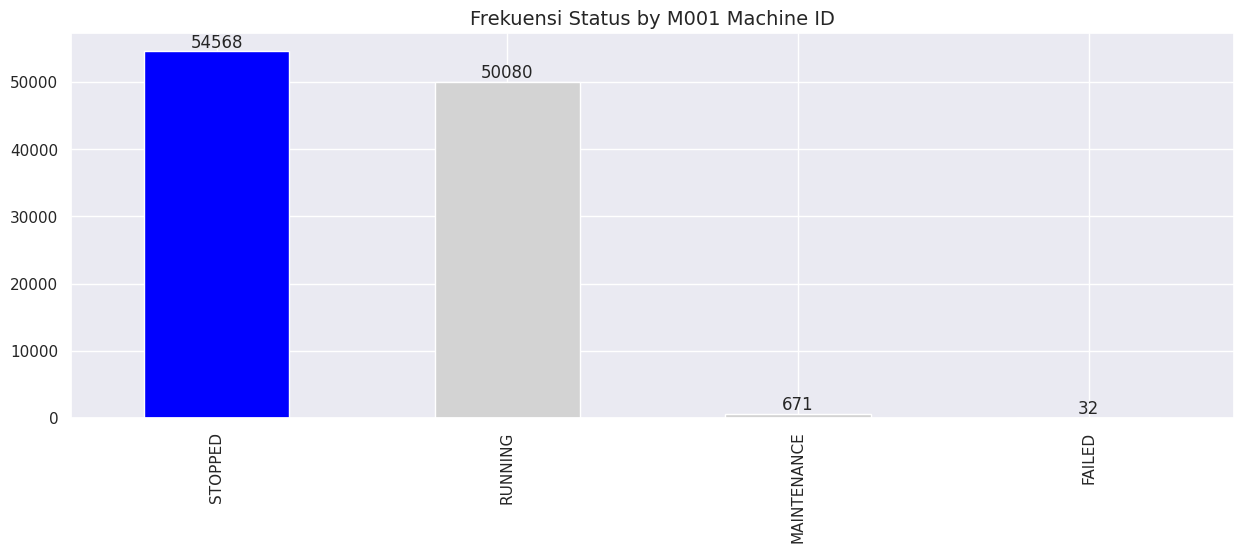

In [27]:
df_by_machine_id = df[df["machine_id"] == "M001"]
plot_frequency_data_kualitatif(df_by_machine_id, "status", "Frekuensi Status by M001 Machine ID")

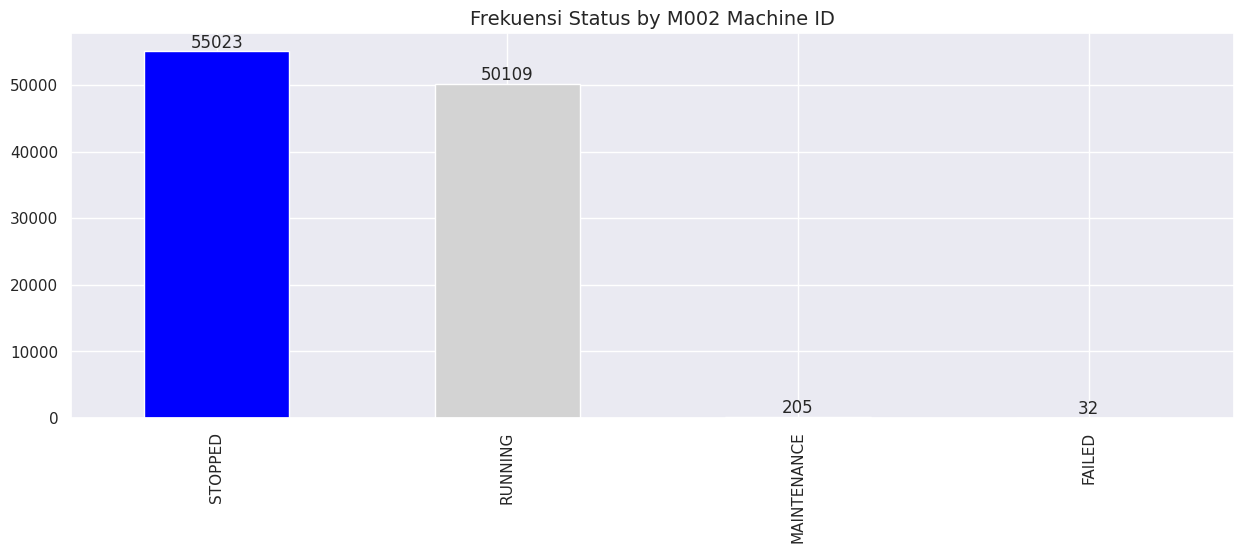

In [28]:
df_by_machine_id = df[df["machine_id"] == "M002"]
plot_frequency_data_kualitatif(df_by_machine_id, "status", "Frekuensi Status by M002 Machine ID")

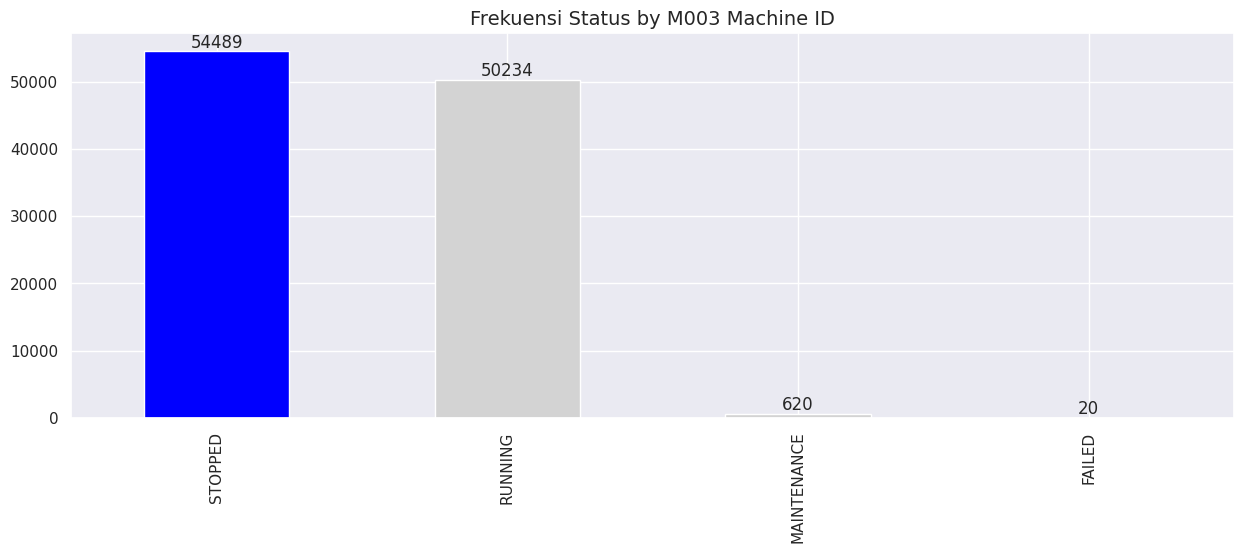

In [29]:
df_by_machine_id = df[df["machine_id"] == "M003"]
plot_frequency_data_kualitatif(df_by_machine_id, "status", "Frekuensi Status by M003 Machine ID")

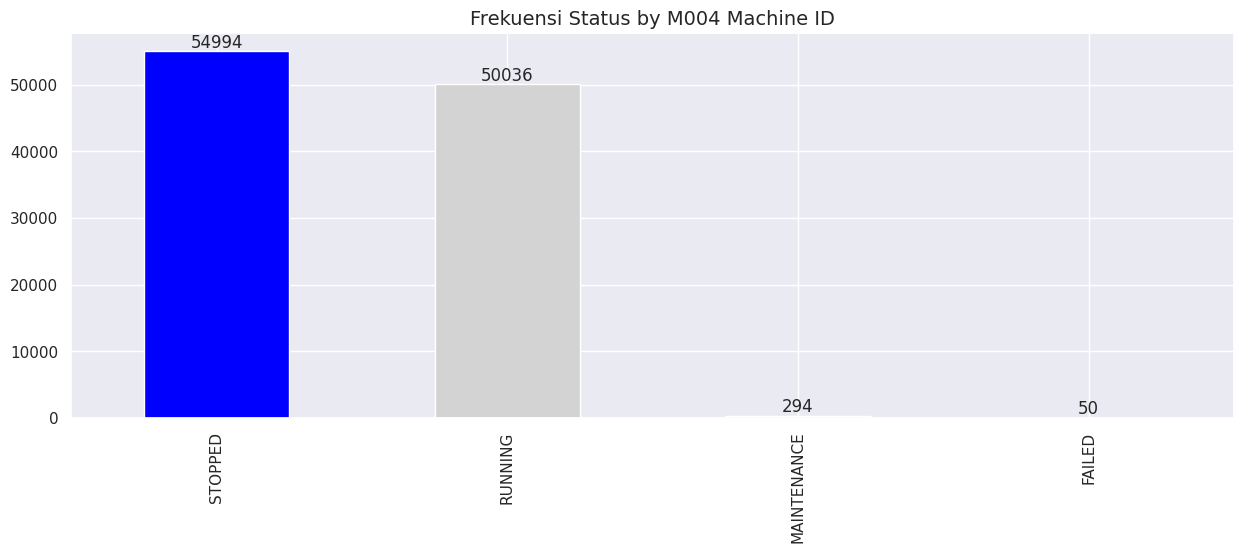

In [30]:
df_by_machine_id = df[df["machine_id"] == "M004"]
plot_frequency_data_kualitatif(df_by_machine_id, "status", "Frekuensi Status by M004 Machine ID")

# Data Preprocessing

In [31]:
df = df[df["machine_id"] == "M003"]
df

,machine_id,temperature_C,vibration_mm_s,pressure_bar,status,operating_hours,ambient_temp_C,shift,production_count,defect_count,good_count
timestamp,,,,,,,,,,,
2024-01-01 00:00:00,M003,15.13,0.008,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:05:00,M003,14.51,0.018,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:10:00,M003,14.94,0.002,0.00,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:15:00,M003,15.38,0.018,0.01,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:20:00,M003,14.90,0.021,0.04,STOPPED,0.00,15.0,Night_Break,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 23:35:00,M003,78.23,5.472,4.52,RUNNING,4018.40,15.0,Evening_Shift,5,1,4
2024-12-31 23:40:00,M003,77.31,5.530,4.76,RUNNING,4018.48,15.0,Evening_Shift,6,0,6
2024-12-31 23:45:00,M003,75.69,5.472,4.62,RUNNING,4018.56,15.0,Evening_Shift,5,2,3


In [32]:
df["status"] = df["status"].apply(lambda x: "STOPPED" if x != "RUNNING" else x)
df

/tmp/ipykernel_58/2661537266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["status"] = df["status"].apply(lambda x: "STOPPED" if x != "RUNNING" else x)


,machine_id,temperature_C,vibration_mm_s,pressure_bar,status,operating_hours,ambient_temp_C,shift,production_count,defect_count,good_count
timestamp,,,,,,,,,,,
2024-01-01 00:00:00,M003,15.13,0.008,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:05:00,M003,14.51,0.018,0.03,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:10:00,M003,14.94,0.002,0.00,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:15:00,M003,15.38,0.018,0.01,STOPPED,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:20:00,M003,14.90,0.021,0.04,STOPPED,0.00,15.0,Night_Break,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 23:35:00,M003,78.23,5.472,4.52,RUNNING,4018.40,15.0,Evening_Shift,5,1,4
2024-12-31 23:40:00,M003,77.31,5.530,4.76,RUNNING,4018.48,15.0,Evening_Shift,6,0,6
2024-12-31 23:45:00,M003,75.69,5.472,4.62,RUNNING,4018.56,15.0,Evening_Shift,5,2,3


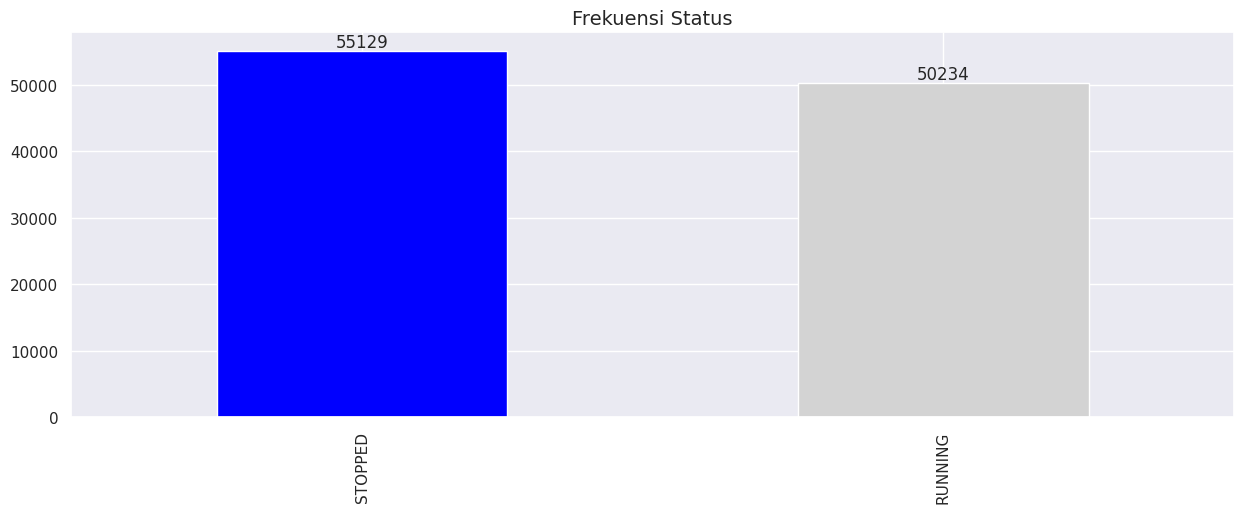

In [33]:
plot_frequency_data_kualitatif(df, "status", "Frekuensi Status")

In [36]:
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

print("--- Mapping Kelas (Diurutkan secara alfabetis) ---")
for index, kelas in enumerate(le.classes_):
    print(f"Angka {index} = Kategori '{kelas}'")
print("\n" + "="*30 + "\n")

--- Mapping Kelas (Diurutkan secara alfabetis) ---
Angka 0 = Kategori 'RUNNING'
Angka 1 = Kategori 'STOPPED'




/tmp/ipykernel_58/4288254375.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['status'] = le.fit_transform(df['status'])


In [37]:
df

,machine_id,temperature_C,vibration_mm_s,pressure_bar,status,operating_hours,ambient_temp_C,shift,production_count,defect_count,good_count
timestamp,,,,,,,,,,,
2024-01-01 00:00:00,M003,15.13,0.008,0.03,1,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:05:00,M003,14.51,0.018,0.03,1,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:10:00,M003,14.94,0.002,0.00,1,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:15:00,M003,15.38,0.018,0.01,1,0.00,15.0,Night_Break,0,0,0
2024-01-01 00:20:00,M003,14.90,0.021,0.04,1,0.00,15.0,Night_Break,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 23:35:00,M003,78.23,5.472,4.52,0,4018.40,15.0,Evening_Shift,5,1,4
2024-12-31 23:40:00,M003,77.31,5.530,4.76,0,4018.48,15.0,Evening_Shift,6,0,6
2024-12-31 23:45:00,M003,75.69,5.472,4.62,0,4018.56,15.0,Evening_Shift,5,2,3


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105363 entries, 2024-01-01 00:00:00 to 2024-12-31 23:55:00
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   machine_id        105363 non-null  object 
 1   temperature_C     105363 non-null  float64
 2   vibration_mm_s    105363 non-null  float64
 3   pressure_bar      105363 non-null  float64
 4   status            105363 non-null  int64  
 5   operating_hours   105363 non-null  float64
 6   ambient_temp_C    105363 non-null  float64
 7   shift             105363 non-null  object 
 8   production_count  105363 non-null  int64  
 9   defect_count      105363 non-null  int64  
 10  good_count        105363 non-null  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 9.6+ MB


In [39]:
df.drop(['machine_id', 'shift', 'production_count', 'defect_count', 'good_count'], axis=1, inplace=True)
df

/tmp/ipykernel_58/1927344647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['machine_id', 'shift', 'production_count', 'defect_count', 'good_count'], axis=1, inplace=True)


,temperature_C,vibration_mm_s,pressure_bar,status,operating_hours,ambient_temp_C
timestamp,,,,,,
2024-01-01 00:00:00,15.13,0.008,0.03,1,0.00,15.0
2024-01-01 00:05:00,14.51,0.018,0.03,1,0.00,15.0
2024-01-01 00:10:00,14.94,0.002,0.00,1,0.00,15.0
2024-01-01 00:15:00,15.38,0.018,0.01,1,0.00,15.0
2024-01-01 00:20:00,14.90,0.021,0.04,1,0.00,15.0
...,...,...,...,...,...,...
2024-12-31 23:35:00,78.23,5.472,4.52,0,4018.40,15.0
2024-12-31 23:40:00,77.31,5.530,4.76,0,4018.48,15.0
2024-12-31 23:45:00,75.69,5.472,4.62,0,4018.56,15.0


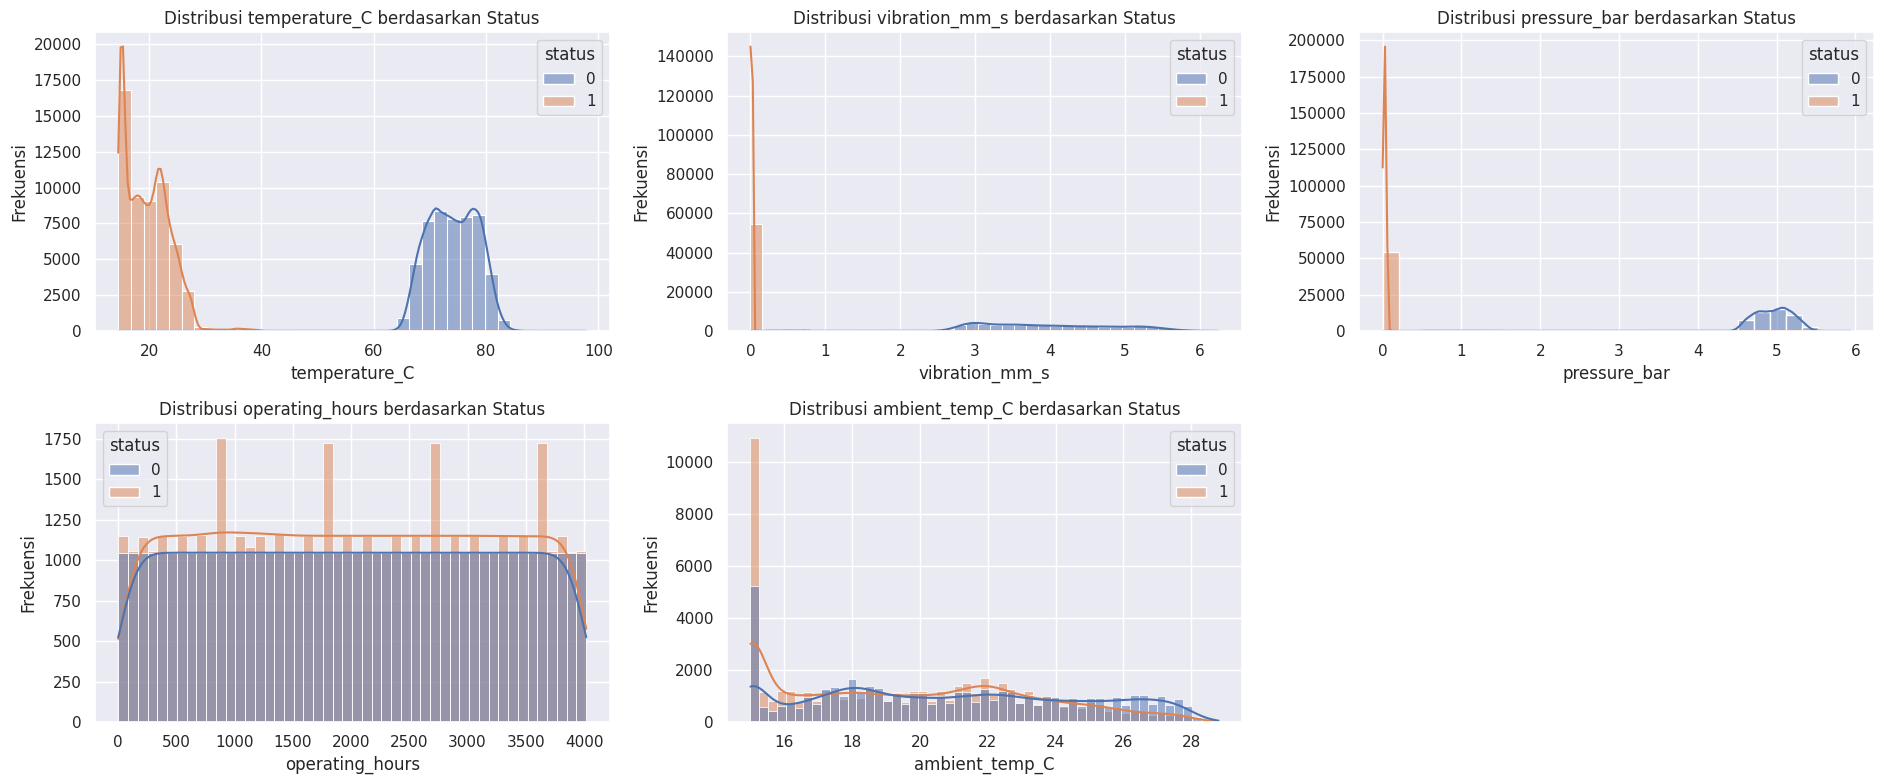

In [40]:
cols_by_status = ['temperature_C', 'vibration_mm_s', 'pressure_bar', 'operating_hours', 'ambient_temp_C']
cols = 3
num_features = len(cols_by_status)
rows = math.ceil(num_features / cols) 

# 4. Membuat kanvas (figure) dan sumbu (axes)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(19, 4 * rows))
axes = axes.flatten() 

# 5. Membuat visualisasi untuk setiap kolom numerik
for i, col in enumerate(cols_by_status):
    sns.histplot(data=df, x=col, kde=True, hue='status', ax=axes[i])
    
    # Menambahkan judul untuk setiap subplot
    axes[i].set_title(f'Distribusi {col} berdasarkan Status', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

# 6. Menyembunyikan subplot yang kosong (jika jumlah kolom ganjil / tidak memenuhi grid)
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j]) # Menghapus axis yang tidak terpakai

# 7. Menyesuaikan jarak antar plot agar tidak tumpang tindih dan menampilkannya
plt.tight_layout()
plt.show()

In [41]:
df_by_status_0 = df[df['status'] == 0][['temperature_C', 'vibration_mm_s', 'pressure_bar', 'status']]
df_by_status_0.describe()

,temperature_C,vibration_mm_s,pressure_bar,status
count,50234.000000,50234.000000,50234.000000,50234.0
mean,74.098966,3.984580,4.964653,0.0
std,4.276882,0.846062,0.226014,0.0
min,61.860000,2.380000,4.300000,0.0
25%,70.630000,3.236000,4.780000,0.0
50%,74.040000,3.881000,4.970000,0.0
75%,77.650000,4.680000,5.140000,0.0
max,86.470000,6.250000,5.680000,0.0


In [42]:
df_by_status_1 = df[df['status'] == 1][['temperature_C', 'vibration_mm_s', 'pressure_bar', 'status']]
df_by_status_1.describe()

,temperature_C,vibration_mm_s,pressure_bar,status
count,55129.000000,55129.000000,55129.000000,55129.0
mean,19.716275,0.021473,0.037107,1.0
std,4.130185,0.076100,0.132311,0.0
min,14.500000,0.000000,0.000000,1.0
25%,15.990000,0.008000,0.010000,1.0
50%,19.380000,0.015000,0.030000,1.0
75%,22.460000,0.023000,0.040000,1.0
max,97.840000,3.818000,5.940000,1.0


In [43]:
df.drop(['operating_hours', 'ambient_temp_C'], axis=1, inplace=True)
df

/tmp/ipykernel_58/2381205688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['operating_hours', 'ambient_temp_C'], axis=1, inplace=True)


,temperature_C,vibration_mm_s,pressure_bar,status
timestamp,,,,
2024-01-01 00:00:00,15.13,0.008,0.03,1
2024-01-01 00:05:00,14.51,0.018,0.03,1
2024-01-01 00:10:00,14.94,0.002,0.00,1
2024-01-01 00:15:00,15.38,0.018,0.01,1
2024-01-01 00:20:00,14.90,0.021,0.04,1
...,...,...,...,...
2024-12-31 23:35:00,78.23,5.472,4.52,0
2024-12-31 23:40:00,77.31,5.530,4.76,0
2024-12-31 23:45:00,75.69,5.472,4.62,0


In [44]:
agg_rules = {
    'temperature_C': ['mean', 'max', 'min', 'std'],
    'vibration_mm_s': ['mean', 'max', 'min', 'std'],
    'pressure_bar': ['mean', 'max', 'min', 'std'],
    'status': ['max']    
}
df = df.resample('1H').agg(agg_rules)
df

/tmp/ipykernel_58/18105307.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('1H').agg(agg_rules)


temperature_C                         vibration_mm_s  \
                             mean    max    min       std           mean   
timestamp                                                                  
2024-01-01 00:00:00     14.921667  15.46  14.50  0.312463       0.015500   
2024-01-01 01:00:00     14.974167  15.41  14.53  0.354900       0.015917   
2024-01-01 02:00:00     15.147500  15.48  14.78  0.268265       0.017083   
2024-01-01 03:00:00     14.985833  15.47  14.50  0.364304       0.012833   
2024-01-01 04:00:00     14.970000  15.29  14.56  0.259440       0.015333   
...                           ...    ...    ...       ...            ...   
2024-12-31 19:00:00     78.150000  80.20  76.24  1.229331       5.343833   
2024-12-31 20:00:00     77.195833  79.38  75.69  1.211089       5.429833   
2024-12-31 21:00:00     77.266667  80.59  73.88  1.631370       5.440000   
2024-12-31 22:00:00     77.492500  79.16  76.12  1.166316       5.425167   
2024-12-31 23:00:00     77.913333  79.33  75.69  0.962094       5.429083   

                                            pressure_bar              \
                       max    min       std         mean   max   min   
timestamp                                                              
2024-01-01 00:00:00  0.030  0.002  0.008405     0.026667  0.04  0.00   
2024-01-01 01:00:00  0.029  0.001  0.010578     0.025000  0.05  0.00   
2024-01-01 02:00:00  0.030  0.004  0.008826     0.020000  0.05  0.00   
2024-01-01 03:00:00  0.028  0.003  0.007814     0.025000  0.04  0.00   
2024-01-01 04:00:00  0.026  0.003  0.008700     0.029167  0.04  0.01   
...                    ...    ...       ...          ...   ...   ...   
2024-12-31 19:00:00  5.816  5.012  0.209213     4.659167  4.76  4.56   
2024-12-31 20:00:00  5.727  5.163  0.176468     4.598333  4.71  4.49   
2024-12-31 21:00:00  5.710  5.177  0.149722     4.595833  4.75  4.52   
2024-12-31 22:00:00  5.886  4.931  0.285993     4.616667  4.70  4.51   
2024-12-31 23:00:00  5.612  5.215  0.119791     4.630833  4.76  4.52   

                              status  
                          std    max  
timestamp                             
2024-01-01 00:00:00  0.015570      1  
2024-01-01 01:00:00  0.016787      1  
2024-01-01 02:00:00  0.017581      1  
2024-01-01 03:00:00  0.015076      1  
2024-01-01 04:00:00  0.013114      1  
...                       ...    ...  
2024-12-31 19:00:00  0.065845      0  
2024-12-31 20:00:00  0.061620      0  
2024-12-31 21:00:00  0.065430      0  
2024-12-31 22:00:00  0.061101      0  
2024-12-31 23:00:00  0.078562      0  

[8784 rows x 13 columns]

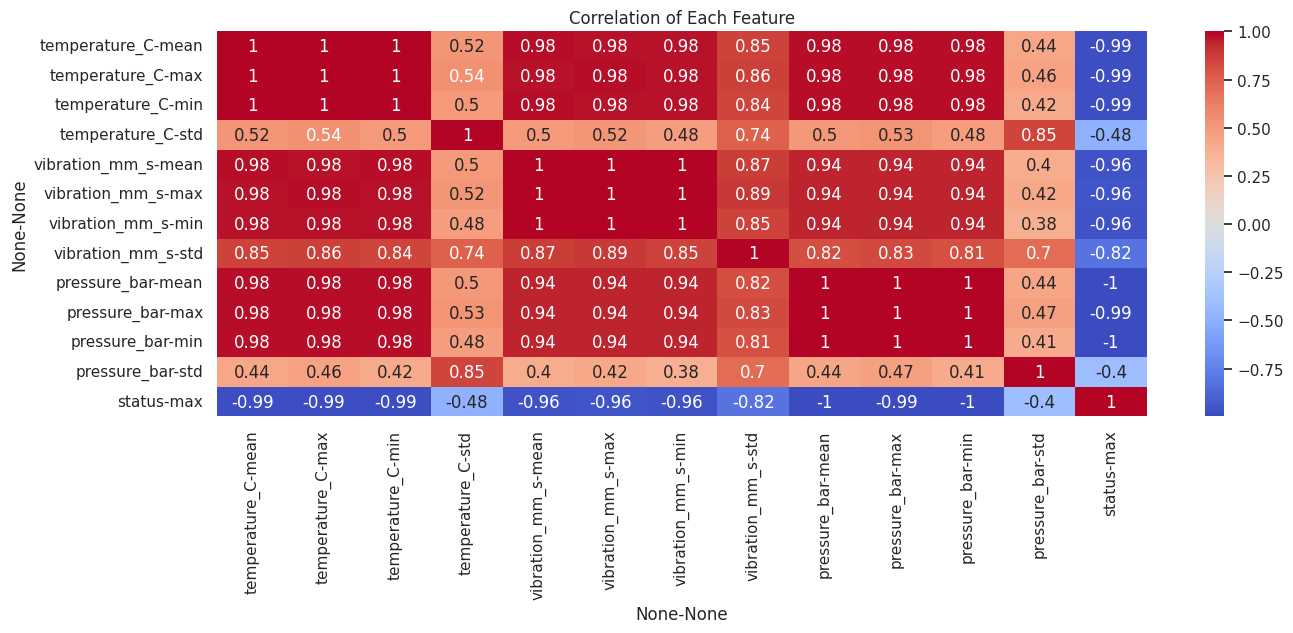

In [45]:
plt.figure(figsize=(15, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm").set_title("Correlation of Each Feature");

In [46]:
df

temperature_C                         vibration_mm_s  \
                             mean    max    min       std           mean   
timestamp                                                                  
2024-01-01 00:00:00     14.921667  15.46  14.50  0.312463       0.015500   
2024-01-01 01:00:00     14.974167  15.41  14.53  0.354900       0.015917   
2024-01-01 02:00:00     15.147500  15.48  14.78  0.268265       0.017083   
2024-01-01 03:00:00     14.985833  15.47  14.50  0.364304       0.012833   
2024-01-01 04:00:00     14.970000  15.29  14.56  0.259440       0.015333   
...                           ...    ...    ...       ...            ...   
2024-12-31 19:00:00     78.150000  80.20  76.24  1.229331       5.343833   
2024-12-31 20:00:00     77.195833  79.38  75.69  1.211089       5.429833   
2024-12-31 21:00:00     77.266667  80.59  73.88  1.631370       5.440000   
2024-12-31 22:00:00     77.492500  79.16  76.12  1.166316       5.425167   
2024-12-31 23:00:00     77.913333  79.33  75.69  0.962094       5.429083   

                                            pressure_bar              \
                       max    min       std         mean   max   min   
timestamp                                                              
2024-01-01 00:00:00  0.030  0.002  0.008405     0.026667  0.04  0.00   
2024-01-01 01:00:00  0.029  0.001  0.010578     0.025000  0.05  0.00   
2024-01-01 02:00:00  0.030  0.004  0.008826     0.020000  0.05  0.00   
2024-01-01 03:00:00  0.028  0.003  0.007814     0.025000  0.04  0.00   
2024-01-01 04:00:00  0.026  0.003  0.008700     0.029167  0.04  0.01   
...                    ...    ...       ...          ...   ...   ...   
2024-12-31 19:00:00  5.816  5.012  0.209213     4.659167  4.76  4.56   
2024-12-31 20:00:00  5.727  5.163  0.176468     4.598333  4.71  4.49   
2024-12-31 21:00:00  5.710  5.177  0.149722     4.595833  4.75  4.52   
2024-12-31 22:00:00  5.886  4.931  0.285993     4.616667  4.70  4.51   
2024-12-31 23:00:00  5.612  5.215  0.119791     4.630833  4.76  4.52   

                              status  
                          std    max  
timestamp                             
2024-01-01 00:00:00  0.015570      1  
2024-01-01 01:00:00  0.016787      1  
2024-01-01 02:00:00  0.017581      1  
2024-01-01 03:00:00  0.015076      1  
2024-01-01 04:00:00  0.013114      1  
...                       ...    ...  
2024-12-31 19:00:00  0.065845      0  
2024-12-31 20:00:00  0.061620      0  
2024-12-31 21:00:00  0.065430      0  
2024-12-31 22:00:00  0.061101      0  
2024-12-31 23:00:00  0.078562      0  

[8784 rows x 13 columns]

In [47]:
df = df[[("status", "max"), ("temperature_C", "mean"), ("vibration_mm_s", "mean"), ("pressure_bar", "mean")]]
df

,status,temperature_C,vibration_mm_s,pressure_bar
,max,mean,mean,mean
timestamp,,,,
2024-01-01 00:00:00,1,14.921667,0.015500,0.026667
2024-01-01 01:00:00,1,14.974167,0.015917,0.025000
2024-01-01 02:00:00,1,15.147500,0.017083,0.020000
2024-01-01 03:00:00,1,14.985833,0.012833,0.025000
2024-01-01 04:00:00,1,14.970000,0.015333,0.029167
...,...,...,...,...
2024-12-31 19:00:00,0,78.150000,5.343833,4.659167
2024-12-31 20:00:00,0,77.195833,5.429833,4.598333


In [48]:
df.columns = [
    "status",
    "temperature_C_mean",
    "vibration_mm_s_mean",
    "pressure_bar_mean"
]
df

,status,temperature_C_mean,vibration_mm_s_mean,pressure_bar_mean
timestamp,,,,
2024-01-01 00:00:00,1,14.921667,0.015500,0.026667
2024-01-01 01:00:00,1,14.974167,0.015917,0.025000
2024-01-01 02:00:00,1,15.147500,0.017083,0.020000
2024-01-01 03:00:00,1,14.985833,0.012833,0.025000
2024-01-01 04:00:00,1,14.970000,0.015333,0.029167
...,...,...,...,...
2024-12-31 19:00:00,0,78.150000,5.343833,4.659167
2024-12-31 20:00:00,0,77.195833,5.429833,4.598333
2024-12-31 21:00:00,0,77.266667,5.440000,4.595833


In [49]:
df.rename({
    'temperature_C_mean': 'temperature_C',
    'vibration_mm_s_mean': 'vibration_mm_s',
    'pressure_bar_mean': 'pressure_bar'
}, axis=1, inplace=True)
df

/tmp/ipykernel_58/2381180663.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename({


,status,temperature_C,vibration_mm_s,pressure_bar
timestamp,,,,
2024-01-01 00:00:00,1,14.921667,0.015500,0.026667
2024-01-01 01:00:00,1,14.974167,0.015917,0.025000
2024-01-01 02:00:00,1,15.147500,0.017083,0.020000
2024-01-01 03:00:00,1,14.985833,0.012833,0.025000
2024-01-01 04:00:00,1,14.970000,0.015333,0.029167
...,...,...,...,...
2024-12-31 19:00:00,0,78.150000,5.343833,4.659167
2024-12-31 20:00:00,0,77.195833,5.429833,4.598333
2024-12-31 21:00:00,0,77.266667,5.440000,4.595833


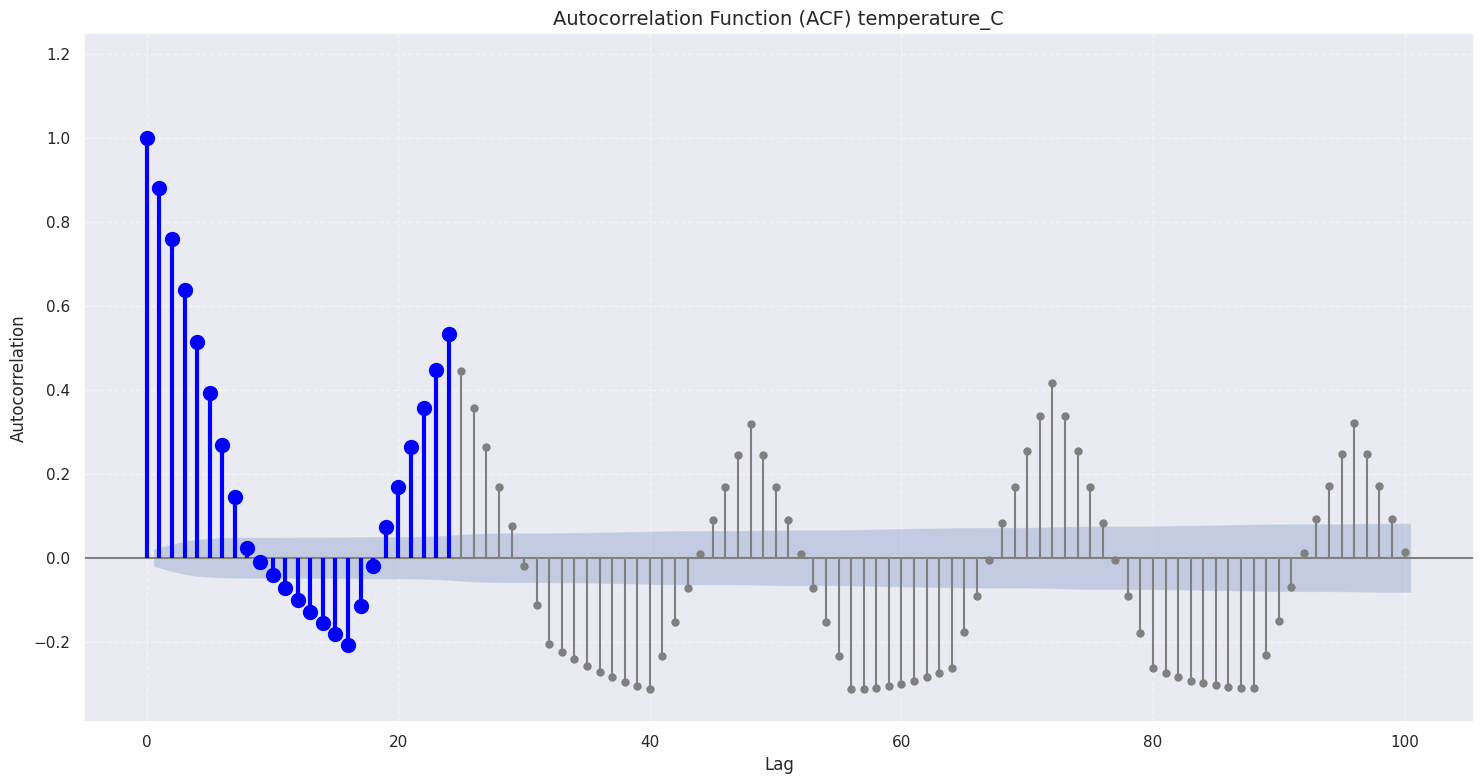

In [50]:
range_target_lags = [i for i in range(25)]
plot_acf_or_pacf(df, "temperature_C", "acf", max_lags=100, target_lags=range_target_lags)

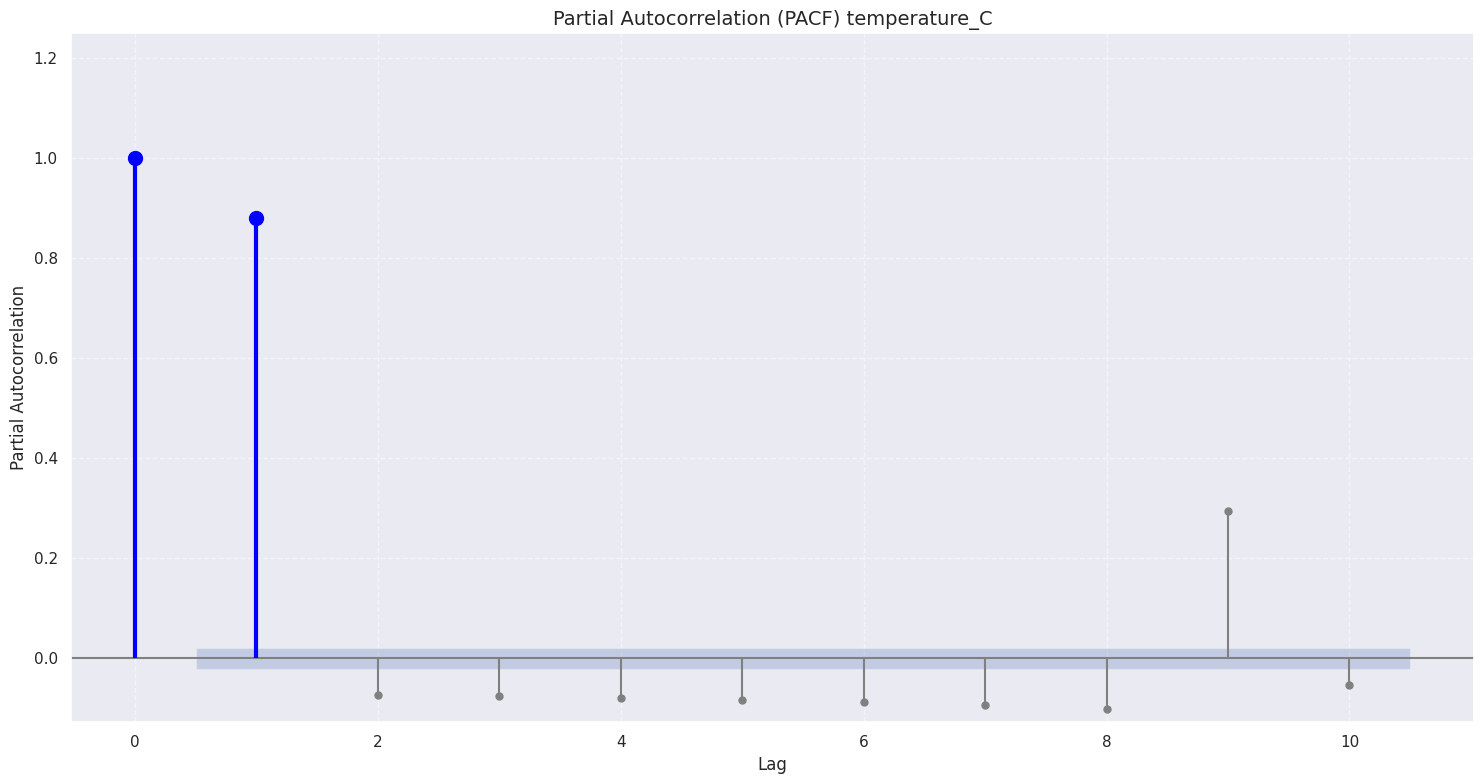

In [51]:
range_target_lags = [i for i in range(2)]
plot_acf_or_pacf(df, "temperature_C", "pacf", max_lags=10, target_lags=range_target_lags)

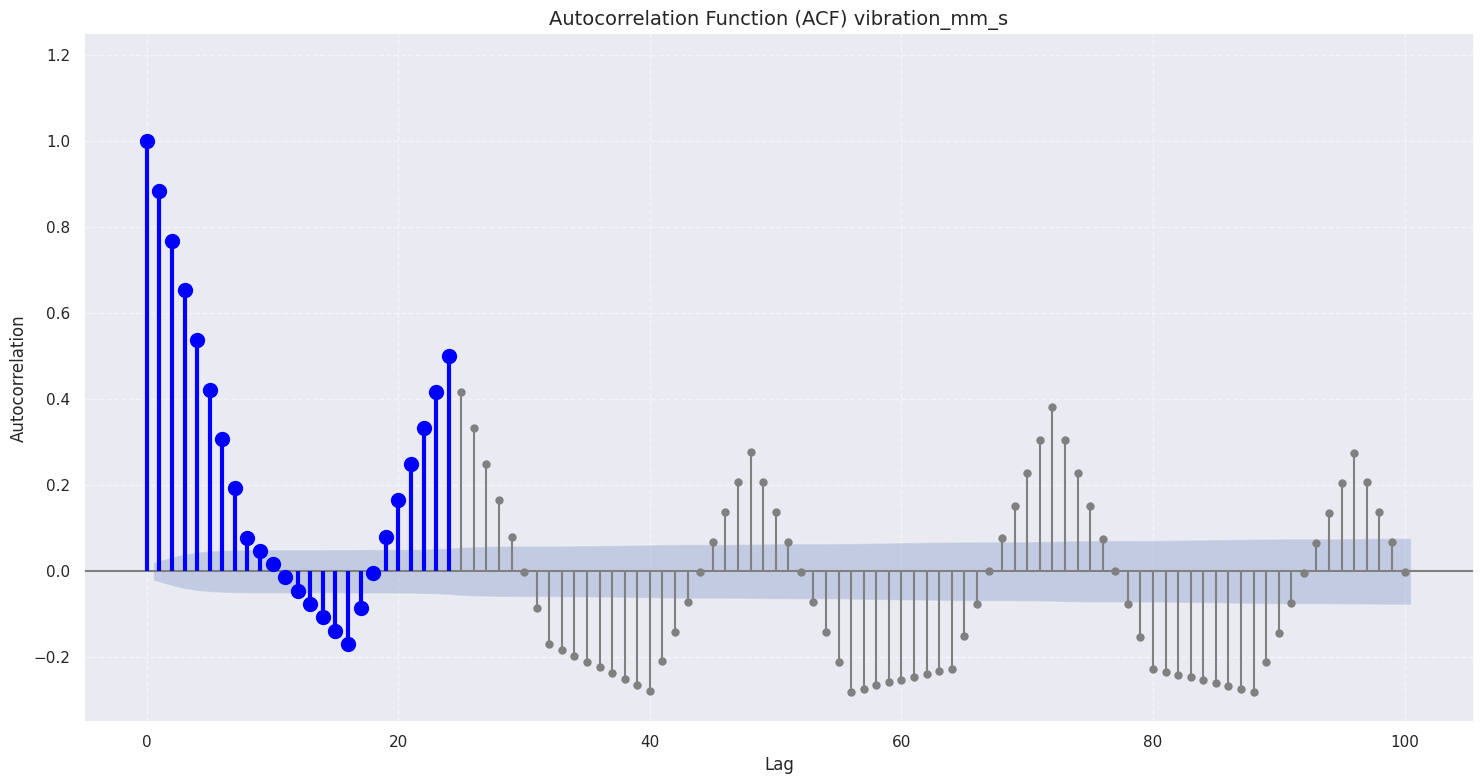

In [52]:
range_target_lags = [i for i in range(25)]
plot_acf_or_pacf(df, "vibration_mm_s", "acf", max_lags=100, target_lags=range_target_lags)

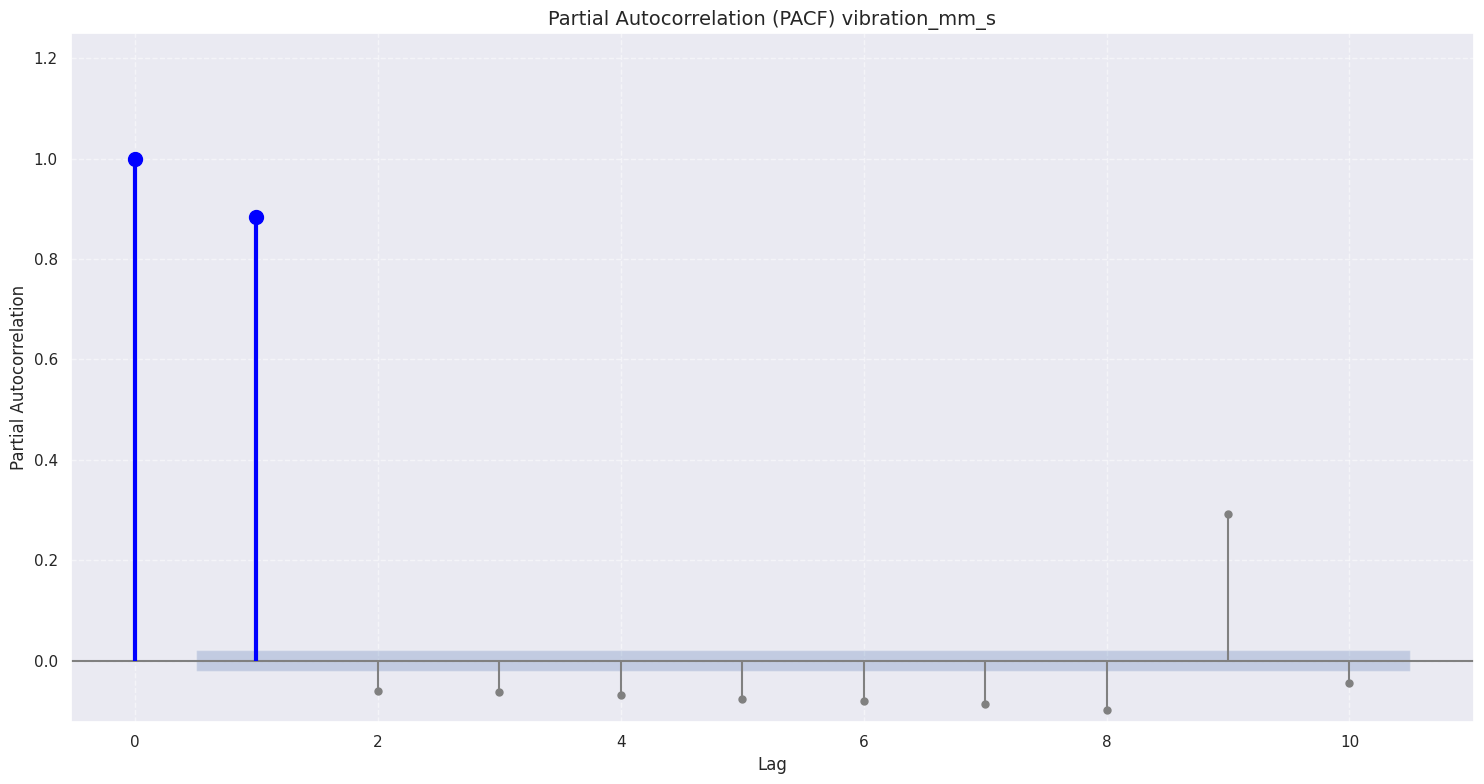

In [53]:
range_target_lags = [i for i in range(2)]
plot_acf_or_pacf(df, "vibration_mm_s", "pacf", max_lags=10, target_lags=range_target_lags)

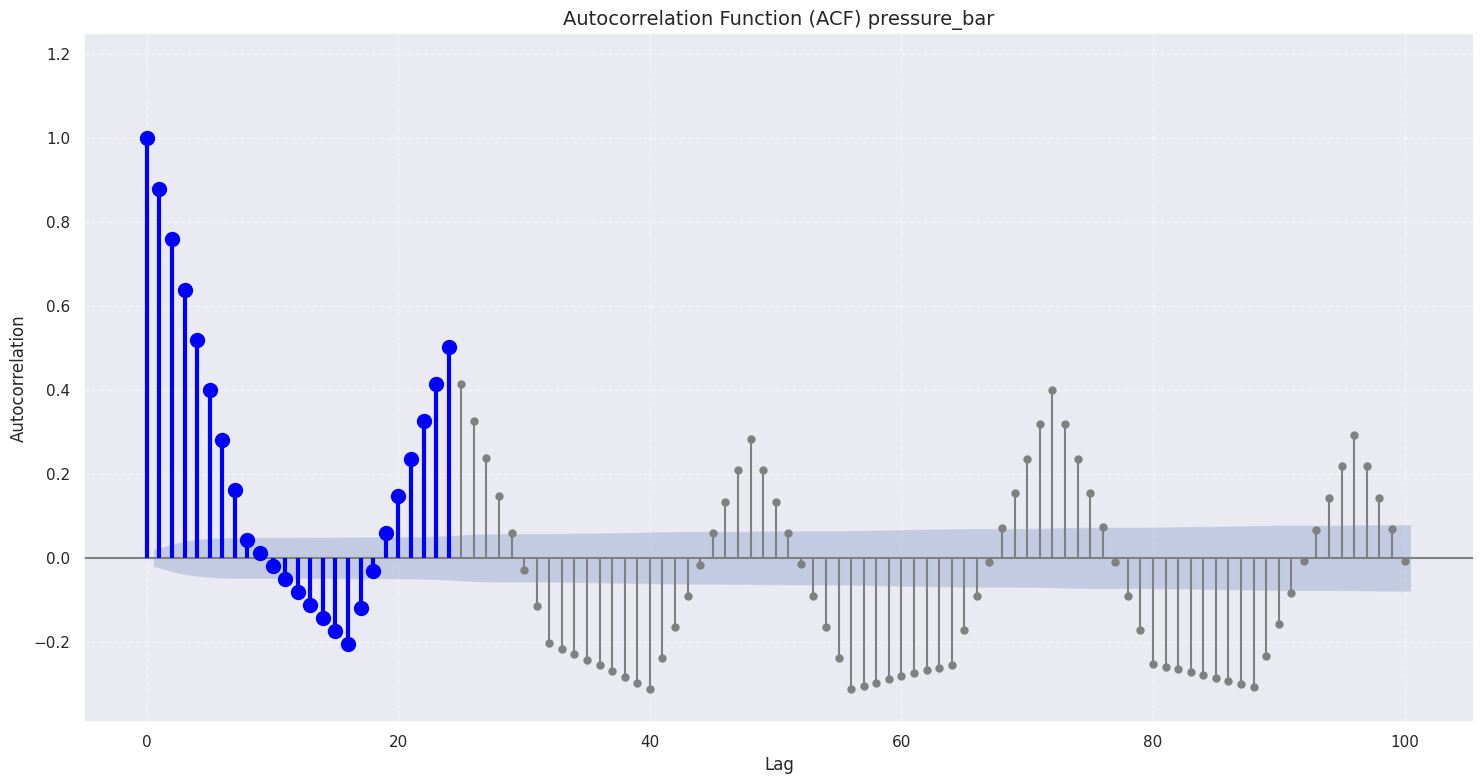

In [54]:
range_target_lags = [i for i in range(25)]
plot_acf_or_pacf(df, "pressure_bar", "acf", max_lags=100, target_lags=range_target_lags)

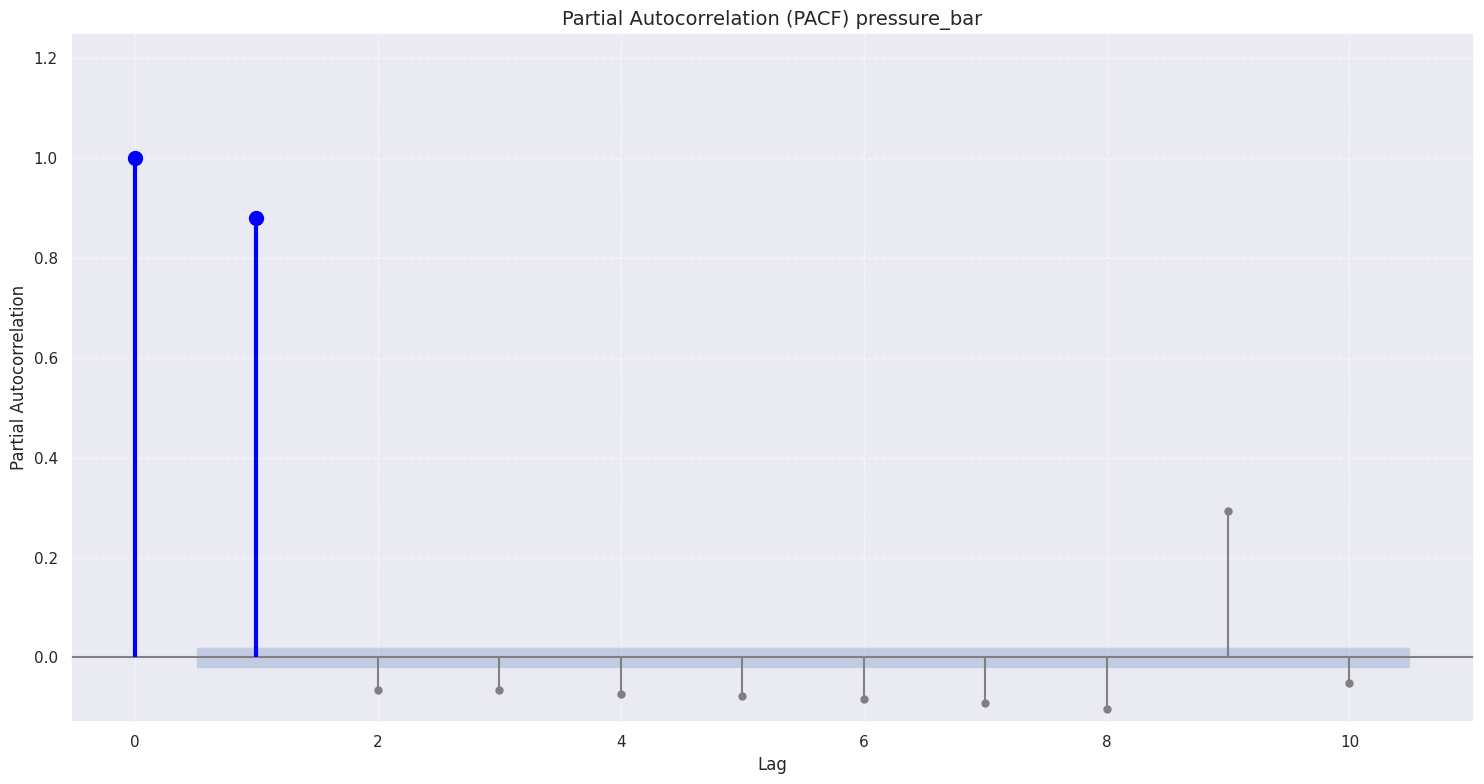

In [55]:
range_target_lags = [i for i in range(2)]
plot_acf_or_pacf(df, "pressure_bar", "pacf", max_lags=10, target_lags=range_target_lags)

In [56]:
df.sample()

,status,temperature_C,vibration_mm_s,pressure_bar
timestamp,,,,
2024-12-29 06:00:00,1,15.175,0.012417,0.02


In [57]:
df["temperature_C_lag_1"] = df["temperature_C"].shift(1)
df["temperature_C_lag_24"] = df["temperature_C"].shift(24)

df["vibration_mm_s_lag_1"] = df["vibration_mm_s"].shift(1)
df["vibration_mm_s_lag_24"] = df["vibration_mm_s"].shift(24)

df["pressure_bar_lag_1"] = df["pressure_bar"].shift(1)
df["pressure_bar_lag_24"] = df["pressure_bar"].shift(24)
df = df.dropna()
df

/tmp/ipykernel_58/2756287211.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["temperature_C_lag_1"] = df["temperature_C"].shift(1)
/tmp/ipykernel_58/2756287211.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["temperature_C_lag_24"] = df["temperature_C"].shift(24)
/tmp/ipykernel_58/2756287211.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pand

,status,temperature_C,vibration_mm_s,pressure_bar,temperature_C_lag_1,temperature_C_lag_24,vibration_mm_s_lag_1,vibration_mm_s_lag_24,pressure_bar_lag_1,pressure_bar_lag_24
timestamp,,,,,,,,,,
2024-01-02 00:00:00,1,15.087500,0.014083,0.026667,66.400833,14.921667,2.829083,0.015500,5.139167,0.026667
2024-01-02 01:00:00,1,14.940000,0.010333,0.025833,15.087500,14.974167,0.014083,0.015917,0.026667,0.025000
2024-01-02 02:00:00,1,14.920833,0.019167,0.025000,14.940000,15.147500,0.010333,0.017083,0.025833,0.020000
2024-01-02 03:00:00,1,14.982500,0.009000,0.026667,14.920833,14.985833,0.019167,0.012833,0.025000,0.025000
2024-01-02 04:00:00,1,15.019167,0.019500,0.028333,14.982500,14.970000,0.009000,0.015333,0.026667,0.029167
...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,0,78.150000,5.343833,4.659167,76.919167,77.647500,5.348000,5.355667,4.635000,4.608333
2024-12-31 20:00:00,0,77.195833,5.429833,4.598333,78.150000,78.485000,5.343833,5.322750,4.659167,4.615000
2024-12-31 21:00:00,0,77.266667,5.440000,4.595833,77.195833,77.771667,5.429833,5.375083,4.598333,4.584167


In [58]:
df.reset_index(inplace=True)
df

,timestamp,status,temperature_C,vibration_mm_s,pressure_bar,temperature_C_lag_1,temperature_C_lag_24,vibration_mm_s_lag_1,vibration_mm_s_lag_24,pressure_bar_lag_1,pressure_bar_lag_24
0,2024-01-02 00:00:00,1,15.087500,0.014083,0.026667,66.400833,14.921667,2.829083,0.015500,5.139167,0.026667
1,2024-01-02 01:00:00,1,14.940000,0.010333,0.025833,15.087500,14.974167,0.014083,0.015917,0.026667,0.025000
2,2024-01-02 02:00:00,1,14.920833,0.019167,0.025000,14.940000,15.147500,0.010333,0.017083,0.025833,0.020000
3,2024-01-02 03:00:00,1,14.982500,0.009000,0.026667,14.920833,14.985833,0.019167,0.012833,0.025000,0.025000
4,2024-01-02 04:00:00,1,15.019167,0.019500,0.028333,14.982500,14.970000,0.009000,0.015333,0.026667,0.029167
...,...,...,...,...,...,...,...,...,...,...,...
8755,2024-12-31 19:00:00,0,78.150000,5.343833,4.659167,76.919167,77.647500,5.348000,5.355667,4.635000,4.608333
8756,2024-12-31 20:00:00,0,77.195833,5.429833,4.598333,78.150000,78.485000,5.343833,5.322750,4.659167,4.615000
8757,2024-12-31 21:00:00,0,77.266667,5.440000,4.595833,77.195833,77.771667,5.429833,5.375083,4.598333,4.584167
8758,2024-12-31 22:00:00,0,77.492500,5.425167,4.616667,77.266667,77.612500,5.440000,5.289167,4.595833,4.636667


In [59]:
df["month"] = df["timestamp"].dt.month
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_holiday"] = df["timestamp"].dt.dayofweek >= 5
df

/tmp/ipykernel_58/1809313924.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["month"] = df["timestamp"].dt.month
/tmp/ipykernel_58/1809313924.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["day_of_week"] = df["timestamp"].dt.dayofweek
/tmp/ipykernel_58/1809313924.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/st

,timestamp,status,temperature_C,vibration_mm_s,pressure_bar,temperature_C_lag_1,temperature_C_lag_24,vibration_mm_s_lag_1,vibration_mm_s_lag_24,pressure_bar_lag_1,pressure_bar_lag_24,month,day_of_week,is_holiday
0,2024-01-02 00:00:00,1,15.087500,0.014083,0.026667,66.400833,14.921667,2.829083,0.015500,5.139167,0.026667,1,1,False
1,2024-01-02 01:00:00,1,14.940000,0.010333,0.025833,15.087500,14.974167,0.014083,0.015917,0.026667,0.025000,1,1,False
2,2024-01-02 02:00:00,1,14.920833,0.019167,0.025000,14.940000,15.147500,0.010333,0.017083,0.025833,0.020000,1,1,False
3,2024-01-02 03:00:00,1,14.982500,0.009000,0.026667,14.920833,14.985833,0.019167,0.012833,0.025000,0.025000,1,1,False
4,2024-01-02 04:00:00,1,15.019167,0.019500,0.028333,14.982500,14.970000,0.009000,0.015333,0.026667,0.029167,1,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2024-12-31 19:00:00,0,78.150000,5.343833,4.659167,76.919167,77.647500,5.348000,5.355667,4.635000,4.608333,12,1,False
8756,2024-12-31 20:00:00,0,77.195833,5.429833,4.598333,78.150000,78.485000,5.343833,5.322750,4.659167,4.615000,12,1,False
8757,2024-12-31 21:00:00,0,77.266667,5.440000,4.595833,77.195833,77.771667,5.429833,5.375083,4.598333,4.584167,12,1,False
8758,2024-12-31 22:00:00,0,77.492500,5.425167,4.616667,77.266667,77.612500,5.440000,5.289167,4.595833,4.636667,12,1,False


In [60]:
df["is_holiday"] = df["is_holiday"].map(lambda x: 1 if x else 0)
df

/tmp/ipykernel_58/3297389599.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["is_holiday"] = df["is_holiday"].map(lambda x: 1 if x else 0)


,timestamp,status,temperature_C,vibration_mm_s,pressure_bar,temperature_C_lag_1,temperature_C_lag_24,vibration_mm_s_lag_1,vibration_mm_s_lag_24,pressure_bar_lag_1,pressure_bar_lag_24,month,day_of_week,is_holiday
0,2024-01-02 00:00:00,1,15.087500,0.014083,0.026667,66.400833,14.921667,2.829083,0.015500,5.139167,0.026667,1,1,0
1,2024-01-02 01:00:00,1,14.940000,0.010333,0.025833,15.087500,14.974167,0.014083,0.015917,0.026667,0.025000,1,1,0
2,2024-01-02 02:00:00,1,14.920833,0.019167,0.025000,14.940000,15.147500,0.010333,0.017083,0.025833,0.020000,1,1,0
3,2024-01-02 03:00:00,1,14.982500,0.009000,0.026667,14.920833,14.985833,0.019167,0.012833,0.025000,0.025000,1,1,0
4,2024-01-02 04:00:00,1,15.019167,0.019500,0.028333,14.982500,14.970000,0.009000,0.015333,0.026667,0.029167,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2024-12-31 19:00:00,0,78.150000,5.343833,4.659167,76.919167,77.647500,5.348000,5.355667,4.635000,4.608333,12,1,0
8756,2024-12-31 20:00:00,0,77.195833,5.429833,4.598333,78.150000,78.485000,5.343833,5.322750,4.659167,4.615000,12,1,0
8757,2024-12-31 21:00:00,0,77.266667,5.440000,4.595833,77.195833,77.771667,5.429833,5.375083,4.598333,4.584167,12,1,0
8758,2024-12-31 22:00:00,0,77.492500,5.425167,4.616667,77.266667,77.612500,5.440000,5.289167,4.595833,4.636667,12,1,0


In [61]:
df.set_index("timestamp", inplace=True)
df

,status,temperature_C,vibration_mm_s,pressure_bar,temperature_C_lag_1,temperature_C_lag_24,vibration_mm_s_lag_1,vibration_mm_s_lag_24,pressure_bar_lag_1,pressure_bar_lag_24,month,day_of_week,is_holiday
timestamp,,,,,,,,,,,,,
2024-01-02 00:00:00,1,15.087500,0.014083,0.026667,66.400833,14.921667,2.829083,0.015500,5.139167,0.026667,1,1,0
2024-01-02 01:00:00,1,14.940000,0.010333,0.025833,15.087500,14.974167,0.014083,0.015917,0.026667,0.025000,1,1,0
2024-01-02 02:00:00,1,14.920833,0.019167,0.025000,14.940000,15.147500,0.010333,0.017083,0.025833,0.020000,1,1,0
2024-01-02 03:00:00,1,14.982500,0.009000,0.026667,14.920833,14.985833,0.019167,0.012833,0.025000,0.025000,1,1,0
2024-01-02 04:00:00,1,15.019167,0.019500,0.028333,14.982500,14.970000,0.009000,0.015333,0.026667,0.029167,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,0,78.150000,5.343833,4.659167,76.919167,77.647500,5.348000,5.355667,4.635000,4.608333,12,1,0
2024-12-31 20:00:00,0,77.195833,5.429833,4.598333,78.150000,78.485000,5.343833,5.322750,4.659167,4.615000,12,1,0
2024-12-31 21:00:00,0,77.266667,5.440000,4.595833,77.195833,77.771667,5.429833,5.375083,4.598333,4.584167,12,1,0


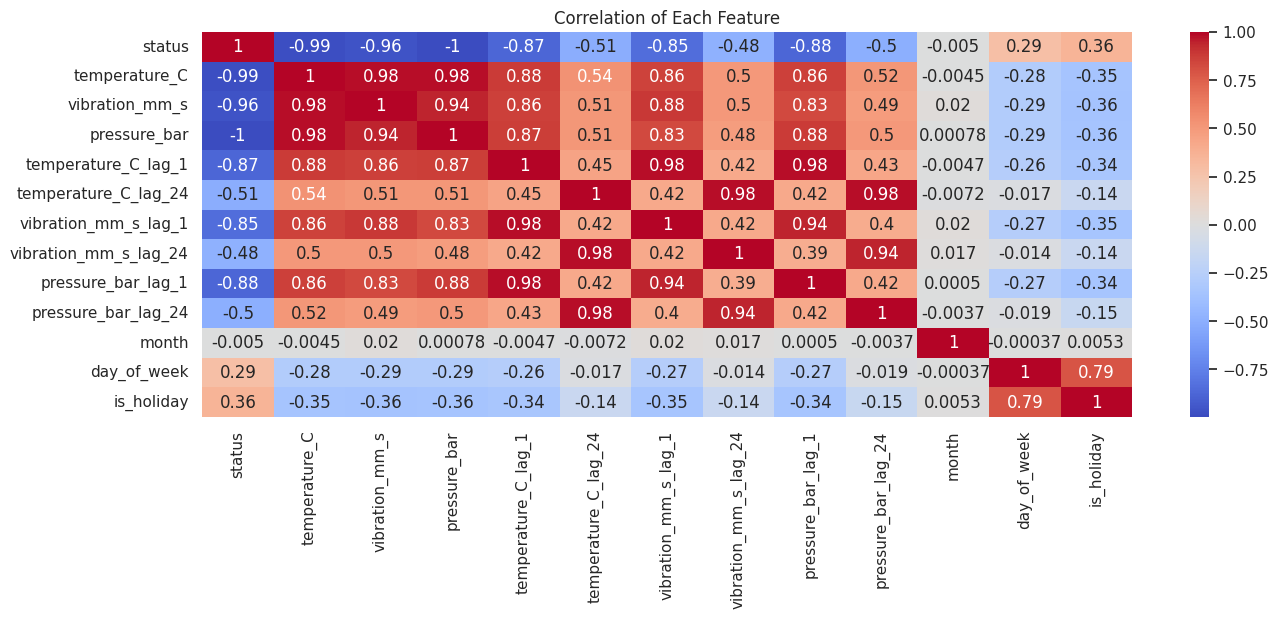

In [62]:
plt.figure(figsize=(15, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm").set_title("Correlation of Each Feature");

In [63]:
df.drop("month", axis=1, inplace=True)
df

/tmp/ipykernel_58/4212581766.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop("month", axis=1, inplace=True)


,status,temperature_C,vibration_mm_s,pressure_bar,temperature_C_lag_1,temperature_C_lag_24,vibration_mm_s_lag_1,vibration_mm_s_lag_24,pressure_bar_lag_1,pressure_bar_lag_24,day_of_week,is_holiday
timestamp,,,,,,,,,,,,
2024-01-02 00:00:00,1,15.087500,0.014083,0.026667,66.400833,14.921667,2.829083,0.015500,5.139167,0.026667,1,0
2024-01-02 01:00:00,1,14.940000,0.010333,0.025833,15.087500,14.974167,0.014083,0.015917,0.026667,0.025000,1,0
2024-01-02 02:00:00,1,14.920833,0.019167,0.025000,14.940000,15.147500,0.010333,0.017083,0.025833,0.020000,1,0
2024-01-02 03:00:00,1,14.982500,0.009000,0.026667,14.920833,14.985833,0.019167,0.012833,0.025000,0.025000,1,0
2024-01-02 04:00:00,1,15.019167,0.019500,0.028333,14.982500,14.970000,0.009000,0.015333,0.026667,0.029167,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,0,78.150000,5.343833,4.659167,76.919167,77.647500,5.348000,5.355667,4.635000,4.608333,1,0
2024-12-31 20:00:00,0,77.195833,5.429833,4.598333,78.150000,78.485000,5.343833,5.322750,4.659167,4.615000,1,0
2024-12-31 21:00:00,0,77.266667,5.440000,4.595833,77.195833,77.771667,5.429833,5.375083,4.598333,4.584167,1,0


# XGBoost

In [64]:
time_series_df = df.copy()
time_series_df.drop('status', axis=1, inplace=True)
time_series_df.reset_index('timestamp', inplace=True)
time_series_df

,timestamp,temperature_C,vibration_mm_s,pressure_bar,temperature_C_lag_1,temperature_C_lag_24,vibration_mm_s_lag_1,vibration_mm_s_lag_24,pressure_bar_lag_1,pressure_bar_lag_24,day_of_week,is_holiday
0,2024-01-02 00:00:00,15.087500,0.014083,0.026667,66.400833,14.921667,2.829083,0.015500,5.139167,0.026667,1,0
1,2024-01-02 01:00:00,14.940000,0.010333,0.025833,15.087500,14.974167,0.014083,0.015917,0.026667,0.025000,1,0
2,2024-01-02 02:00:00,14.920833,0.019167,0.025000,14.940000,15.147500,0.010333,0.017083,0.025833,0.020000,1,0
3,2024-01-02 03:00:00,14.982500,0.009000,0.026667,14.920833,14.985833,0.019167,0.012833,0.025000,0.025000,1,0
4,2024-01-02 04:00:00,15.019167,0.019500,0.028333,14.982500,14.970000,0.009000,0.015333,0.026667,0.029167,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2024-12-31 19:00:00,78.150000,5.343833,4.659167,76.919167,77.647500,5.348000,5.355667,4.635000,4.608333,1,0
8756,2024-12-31 20:00:00,77.195833,5.429833,4.598333,78.150000,78.485000,5.343833,5.322750,4.659167,4.615000,1,0
8757,2024-12-31 21:00:00,77.266667,5.440000,4.595833,77.195833,77.771667,5.429833,5.375083,4.598333,4.584167,1,0
8758,2024-12-31 22:00:00,77.492500,5.425167,4.616667,77.266667,77.612500,5.440000,5.289167,4.595833,4.636667,1,0


In [65]:
HORIZON = 24
sensors = ['temperature_C', 'vibration_mm_s', 'pressure_bar']
targets = []

for i in range(1, HORIZON + 1):
    for col in sensors:
        target_name = f'{col}_t_{i}'
        time_series_df[target_name] = time_series_df[col].shift(-i)
        targets.append(target_name)

time_series_df.dropna(inplace=True)
time_series_df

,timestamp,temperature_C,vibration_mm_s,pressure_bar,temperature_C_lag_1,temperature_C_lag_24,vibration_mm_s_lag_1,vibration_mm_s_lag_24,pressure_bar_lag_1,pressure_bar_lag_24,...,pressure_bar_t_21,temperature_C_t_22,vibration_mm_s_t_22,pressure_bar_t_22,temperature_C_t_23,vibration_mm_s_t_23,pressure_bar_t_23,temperature_C_t_24,vibration_mm_s_t_24,pressure_bar_t_24
0,2024-01-02 00:00:00,15.087500,0.014083,0.026667,66.400833,14.921667,2.829083,0.015500,5.139167,0.026667,...,4.660833,76.090000,4.597750,4.691667,75.806667,4.698333,4.690833,15.435000,0.015167,0.024167
1,2024-01-02 01:00:00,14.940000,0.010333,0.025833,15.087500,14.974167,0.014083,0.015917,0.026667,0.025000,...,4.691667,75.806667,4.698333,4.690833,15.435000,0.015167,0.024167,15.685000,0.018167,0.020833
2,2024-01-02 02:00:00,14.920833,0.019167,0.025000,14.940000,15.147500,0.010333,0.017083,0.025833,0.020000,...,4.690833,15.435000,0.015167,0.024167,15.685000,0.018167,0.020833,15.852500,0.016917,0.017500
3,2024-01-02 03:00:00,14.982500,0.009000,0.026667,14.920833,14.985833,0.019167,0.012833,0.025000,0.025000,...,0.024167,15.685000,0.018167,0.020833,15.852500,0.016917,0.017500,16.068333,0.013583,0.030833
4,2024-01-02 04:00:00,15.019167,0.019500,0.028333,14.982500,14.970000,0.009000,0.015333,0.026667,0.029167,...,0.020833,15.852500,0.016917,0.017500,16.068333,0.013583,0.030833,16.846667,0.015167,0.018333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8731,2024-12-30 19:00:00,77.647500,5.355667,4.608333,77.815833,14.999167,5.424167,0.012083,4.592500,0.026667,...,4.608333,78.000833,5.514250,4.624167,76.919167,5.348000,4.635000,78.150000,5.343833,4.659167
8732,2024-12-30 20:00:00,78.485000,5.322750,4.615000,77.647500,14.989167,5.355667,0.017583,4.608333,0.025833,...,4.624167,76.919167,5.348000,4.635000,78.150000,5.343833,4.659167,77.195833,5.429833,4.598333
8733,2024-12-30 21:00:00,77.771667,5.375083,4.584167,78.485000,14.905000,5.322750,0.015500,4.615000,0.023333,...,4.635000,78.150000,5.343833,4.659167,77.195833,5.429833,4.598333,77.266667,5.440000,4.595833
8734,2024-12-30 22:00:00,77.612500,5.289167,4.636667,77.771667,15.002500,5.375083,0.017917,4.584167,0.027500,...,4.659167,77.195833,5.429833,4.598333,77.266667,5.440000,4.595833,77.492500,5.425167,4.616667


In [66]:
features = [feature for feature in df.columns if feature.endswith('lag_1') or feature.endswith('lag_24')]
features

['temperature_C_lag_1',
 'temperature_C_lag_24',
 'vibration_mm_s_lag_1',
 'vibration_mm_s_lag_24',
 'pressure_bar_lag_1',
 'pressure_bar_lag_24']

In [67]:
targets

['temperature_C_t_1',
 'vibration_mm_s_t_1',
 'pressure_bar_t_1',
 'temperature_C_t_2',
 'vibration_mm_s_t_2',
 'pressure_bar_t_2',
 'temperature_C_t_3',
 'vibration_mm_s_t_3',
 'pressure_bar_t_3',
 'temperature_C_t_4',
 'vibration_mm_s_t_4',
 'pressure_bar_t_4',
 'temperature_C_t_5',
 'vibration_mm_s_t_5',
 'pressure_bar_t_5',
 'temperature_C_t_6',
 'vibration_mm_s_t_6',
 'pressure_bar_t_6',
 'temperature_C_t_7',
 'vibration_mm_s_t_7',
 'pressure_bar_t_7',
 'temperature_C_t_8',
 'vibration_mm_s_t_8',
 'pressure_bar_t_8',
 'temperature_C_t_9',
 'vibration_mm_s_t_9',
 'pressure_bar_t_9',
 'temperature_C_t_10',
 'vibration_mm_s_t_10',
 'pressure_bar_t_10',
 'temperature_C_t_11',
 'vibration_mm_s_t_11',
 'pressure_bar_t_11',
 'temperature_C_t_12',
 'vibration_mm_s_t_12',
 'pressure_bar_t_12',
 'temperature_C_t_13',
 'vibration_mm_s_t_13',
 'pressure_bar_t_13',
 'temperature_C_t_14',
 'vibration_mm_s_t_14',
 'pressure_bar_t_14',
 'temperature_C_t_15',
 'vibration_mm_s_t_15',
 'pressure_bar

In [68]:
# Definisikan Input (X) dan Output (Y)
X = time_series_df[features]
Y = time_series_df[targets]
X.head()

,temperature_C_lag_1,temperature_C_lag_24,vibration_mm_s_lag_1,vibration_mm_s_lag_24,pressure_bar_lag_1,pressure_bar_lag_24
0,66.400833,14.921667,2.829083,0.015500,5.139167,0.026667
1,15.087500,14.974167,0.014083,0.015917,0.026667,0.025000
2,14.940000,15.147500,0.010333,0.017083,0.025833,0.020000
3,14.920833,14.985833,0.019167,0.012833,0.025000,0.025000
4,14.982500,14.970000,0.009000,0.015333,0.026667,0.029167


In [69]:
Y.head()

,temperature_C_t_1,vibration_mm_s_t_1,pressure_bar_t_1,temperature_C_t_2,vibration_mm_s_t_2,pressure_bar_t_2,temperature_C_t_3,vibration_mm_s_t_3,pressure_bar_t_3,temperature_C_t_4,...,pressure_bar_t_21,temperature_C_t_22,vibration_mm_s_t_22,pressure_bar_t_22,temperature_C_t_23,vibration_mm_s_t_23,pressure_bar_t_23,temperature_C_t_24,vibration_mm_s_t_24,pressure_bar_t_24
0,14.940000,0.010333,0.025833,14.920833,0.019167,0.025000,14.982500,0.009000,0.026667,15.019167,...,4.660833,76.090000,4.597750,4.691667,75.806667,4.698333,4.690833,15.435000,0.015167,0.024167
1,14.920833,0.019167,0.025000,14.982500,0.009000,0.026667,15.019167,0.019500,0.028333,15.437500,...,4.691667,75.806667,4.698333,4.690833,15.435000,0.015167,0.024167,15.685000,0.018167,0.020833
2,14.982500,0.009000,0.026667,15.019167,0.019500,0.028333,15.437500,0.018250,0.020833,16.497500,...,4.690833,15.435000,0.015167,0.024167,15.685000,0.018167,0.020833,15.852500,0.016917,0.017500
3,15.019167,0.019500,0.028333,15.437500,0.018250,0.020833,16.497500,0.016750,0.030000,17.199167,...,0.024167,15.685000,0.018167,0.020833,15.852500,0.016917,0.017500,16.068333,0.013583,0.030833
4,15.437500,0.018250,0.020833,16.497500,0.016750,0.030000,17.199167,0.015083,0.015833,76.806667,...,0.020833,15.852500,0.016917,0.017500,16.068333,0.013583,0.030833,16.846667,0.015167,0.018333


In [70]:
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
Y_train, Y_test = Y.iloc[:split_idx], Y.iloc[split_idx:]

print(f"Dimensi Input (X)  : {X_train.shape[1]} kolom")
print(f"Dimensi Target (Y) : {Y_train.shape[1]} kolom (3 Sensor x 24 Jam)\n")

Dimensi Input (X)  : 6 kolom
Dimensi Target (Y) : 72 kolom (3 Sensor x 24 Jam)



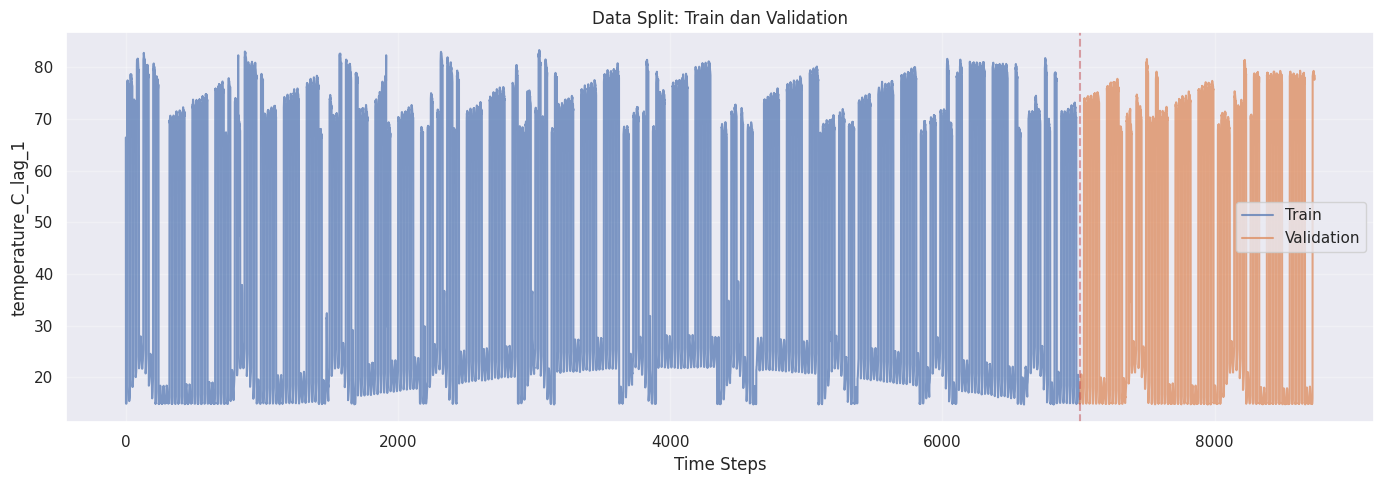

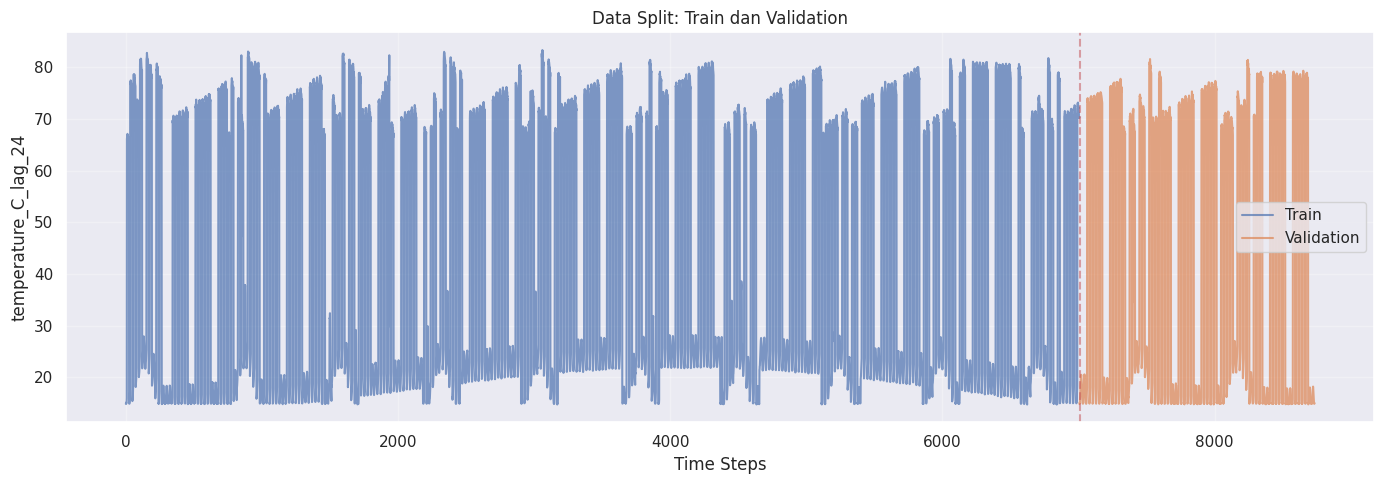

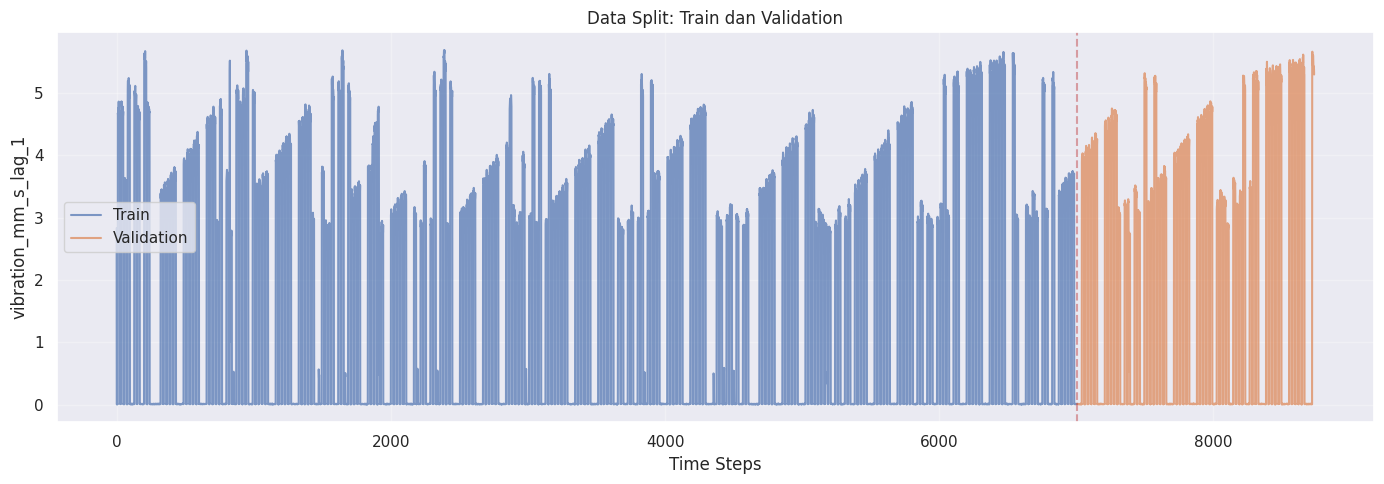

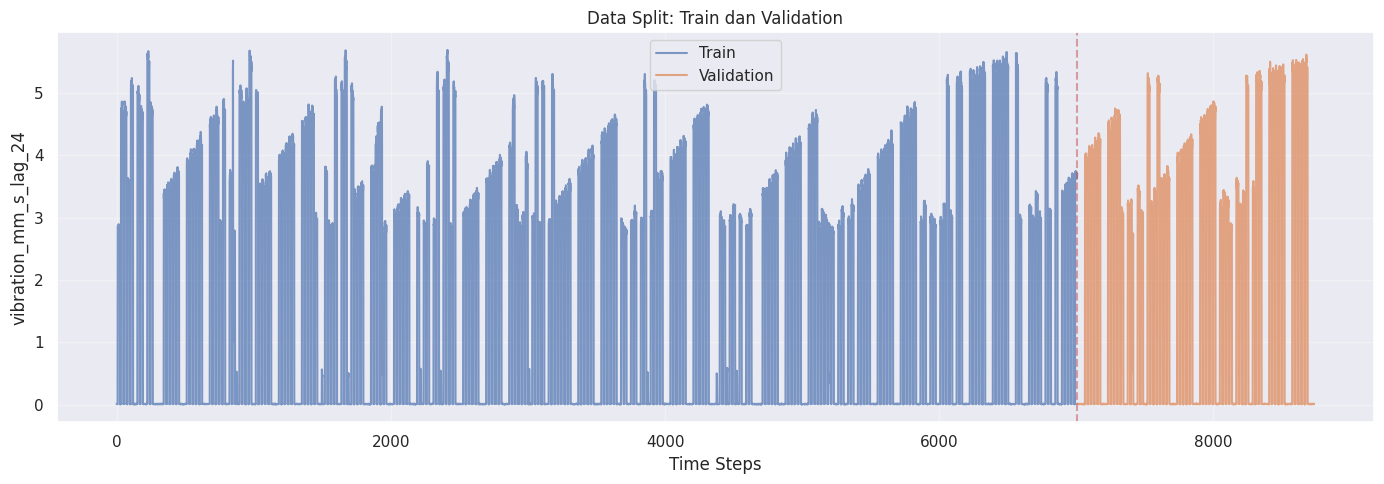

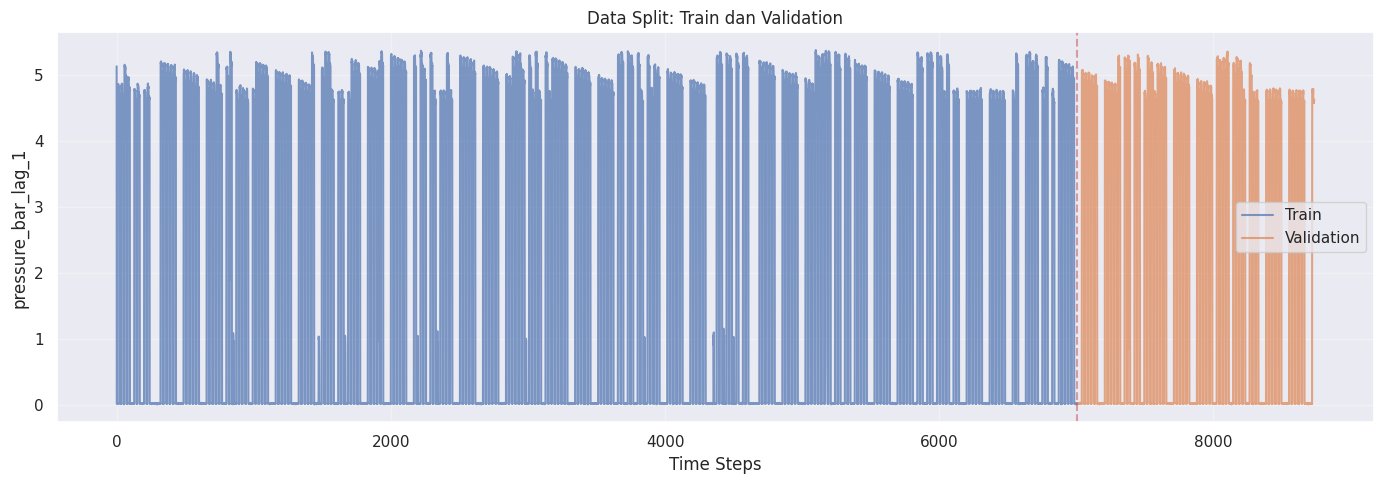

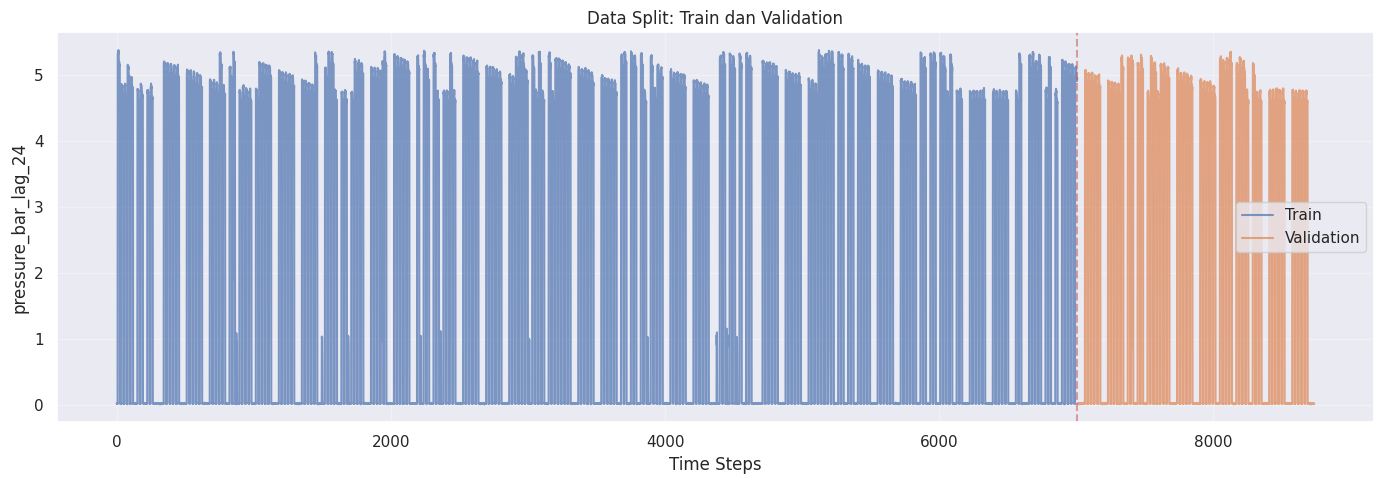

In [71]:
for i, col in enumerate(X_train):
    plt.figure(figsize=(14, 5))
    plt.plot(range(len(X_train)), X_train.iloc[:, i], label='Train', alpha=0.7)
    plt.plot(range(len(X_train), len(X_train) + len(X_test)), X_test.iloc[:, i], label='Validation', alpha=0.7)
    
    plt.axvline(x=len(X_train), color='r', linestyle='--', alpha=0.5)
    
    plt.title('Data Split: Train dan Validation')
    plt.xlabel('Time Steps')
    plt.ylabel(col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

In [72]:
base_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=4, 
    random_state=42,
    objective='reg:absoluteerror'
)

# RegressorChain akan melatih target dari t1(temp, vib, press) lalu t2, dst secara berurutan
chain_model = RegressorChain(base_estimator=base_model)
chain_model.fit(X_train, Y_train)

RegressorChain(base_estimator=XGBRegressor(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate=0.05, max_bin=None,
                                           max_cat_threshold=None,
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=4,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=100, n_jobs=None,
                                           num_parallel_tree=None, ...))

In [73]:
Y_pred = chain_model.predict(X_test)
Y_pred_df = pd.DataFrame(Y_pred, columns=targets, index=Y_test.index)
Y_pred_df

,temperature_C_t_1,vibration_mm_s_t_1,pressure_bar_t_1,temperature_C_t_2,vibration_mm_s_t_2,pressure_bar_t_2,temperature_C_t_3,vibration_mm_s_t_3,pressure_bar_t_3,temperature_C_t_4,...,pressure_bar_t_21,temperature_C_t_22,vibration_mm_s_t_22,pressure_bar_t_22,temperature_C_t_23,vibration_mm_s_t_23,pressure_bar_t_23,temperature_C_t_24,vibration_mm_s_t_24,pressure_bar_t_24
7008,15.082264,0.014885,0.025315,15.117571,0.015066,0.024986,15.418480,0.014897,0.025237,16.216249,...,0.024827,16.224564,0.014969,0.025240,15.997590,0.015092,0.024723,16.119858,0.015116,0.024814
7009,15.092675,0.015011,0.025067,15.124697,0.014920,0.024986,15.418480,0.015128,0.025237,15.869298,...,0.025036,16.224564,0.014969,0.025029,16.031551,0.015092,0.025221,16.161304,0.015116,0.024814
7010,16.776184,0.014923,0.025371,17.385939,0.015121,0.024937,18.315237,0.015222,0.024986,18.840088,...,0.024789,17.285141,0.015064,0.025029,16.648361,0.015100,0.024723,16.419409,0.015095,0.024794
7011,14.991938,0.015077,0.025129,15.119686,0.014920,0.024891,15.371211,0.015152,0.024839,15.732656,...,0.024715,20.049213,0.015058,0.025058,20.262960,0.015169,0.025207,20.405487,0.015087,0.024794
7012,17.589149,0.014823,0.024803,17.833145,0.015162,0.025007,18.583437,0.015276,0.025028,19.529232,...,0.025090,19.485725,0.015088,0.025058,19.737991,0.015187,0.024695,19.925243,0.015113,0.024794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8731,70.472755,3.959392,4.587288,67.884476,3.381889,4.741102,47.983185,1.700503,4.169308,69.778152,...,0.075415,27.822983,0.047929,0.108524,27.767622,0.056734,0.122089,27.952194,0.015256,0.029294
8732,69.836838,3.959392,4.587288,59.667984,1.646677,4.157533,46.694450,0.790192,1.052331,39.348339,...,0.024741,24.098366,0.014944,0.025058,23.895908,0.015021,0.024849,23.740290,0.015103,0.029323
8733,61.021271,1.599233,4.084461,61.241463,2.180868,4.181966,46.613594,0.785716,0.979037,39.348339,...,0.024573,24.578045,0.014884,0.025179,24.182585,0.015021,0.025221,23.833704,0.015103,0.029323
8734,70.472755,3.959392,4.587288,60.654152,1.646598,4.157533,34.861519,0.790181,1.052733,39.348339,...,0.024741,24.098366,0.014944,0.024938,23.895908,0.015021,0.024731,23.736605,0.015103,0.029323


## Future Predictions

In [90]:
time_train = time_series_df.loc[X_train.index, 'timestamp']
time_test = time_series_df.loc[X_test.index, 'timestamp']

last_X_test = X_test.iloc[[-1]]
last_time = time_test.iloc[-1]
last_X_test.to_csv('test_data_tgl_2024_12_30_23:00.csv')
last_X_test

,temperature_C_lag_1,temperature_C_lag_24,vibration_mm_s_lag_1,vibration_mm_s_lag_24,pressure_bar_lag_1,pressure_bar_lag_24
8735,77.6125,15.05,5.289167,0.017167,4.636667,0.020833


In [88]:
last_time

Timestamp('2024-12-30 23:00:00')

In [75]:
future_pred_array = chain_model.predict(last_X_test)
future_pred_df = pd.DataFrame(future_pred_array, columns=targets)
future_pred_df

,temperature_C_t_1,vibration_mm_s_t_1,pressure_bar_t_1,temperature_C_t_2,vibration_mm_s_t_2,pressure_bar_t_2,temperature_C_t_3,vibration_mm_s_t_3,pressure_bar_t_3,temperature_C_t_4,...,pressure_bar_t_21,temperature_C_t_22,vibration_mm_s_t_22,pressure_bar_t_22,temperature_C_t_23,vibration_mm_s_t_23,pressure_bar_t_23,temperature_C_t_24,vibration_mm_s_t_24,pressure_bar_t_24
0,69.836838,3.959392,4.595642,59.667984,1.648276,4.15745,46.705574,0.789321,1.052289,39.348339,...,0.025041,24.098366,0.014944,0.025058,23.895908,0.015021,0.024849,23.74029,0.015103,0.028975


In [76]:
# Membuat sumbu waktu masa depan (24 Jam ke depan dari titik terakhir)
time_future = pd.date_range(start=last_time + pd.Timedelta(hours=1), periods=HORIZON, freq='1H')
time_future

/tmp/ipykernel_58/3734483170.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_future = pd.date_range(start=last_time + pd.Timedelta(hours=1), periods=HORIZON, freq='1H')


DatetimeIndex(['2024-12-31 00:00:00', '2024-12-31 01:00:00',
               '2024-12-31 02:00:00', '2024-12-31 03:00:00',
               '2024-12-31 04:00:00', '2024-12-31 05:00:00',
               '2024-12-31 06:00:00', '2024-12-31 07:00:00',
               '2024-12-31 08:00:00', '2024-12-31 09:00:00',
               '2024-12-31 10:00:00', '2024-12-31 11:00:00',
               '2024-12-31 12:00:00', '2024-12-31 13:00:00',
               '2024-12-31 14:00:00', '2024-12-31 15:00:00',
               '2024-12-31 16:00:00', '2024-12-31 17:00:00',
               '2024-12-31 18:00:00', '2024-12-31 19:00:00',
               '2024-12-31 20:00:00', '2024-12-31 21:00:00',
               '2024-12-31 22:00:00', '2024-12-31 23:00:00'],
              dtype='datetime64[ns]', freq='h')

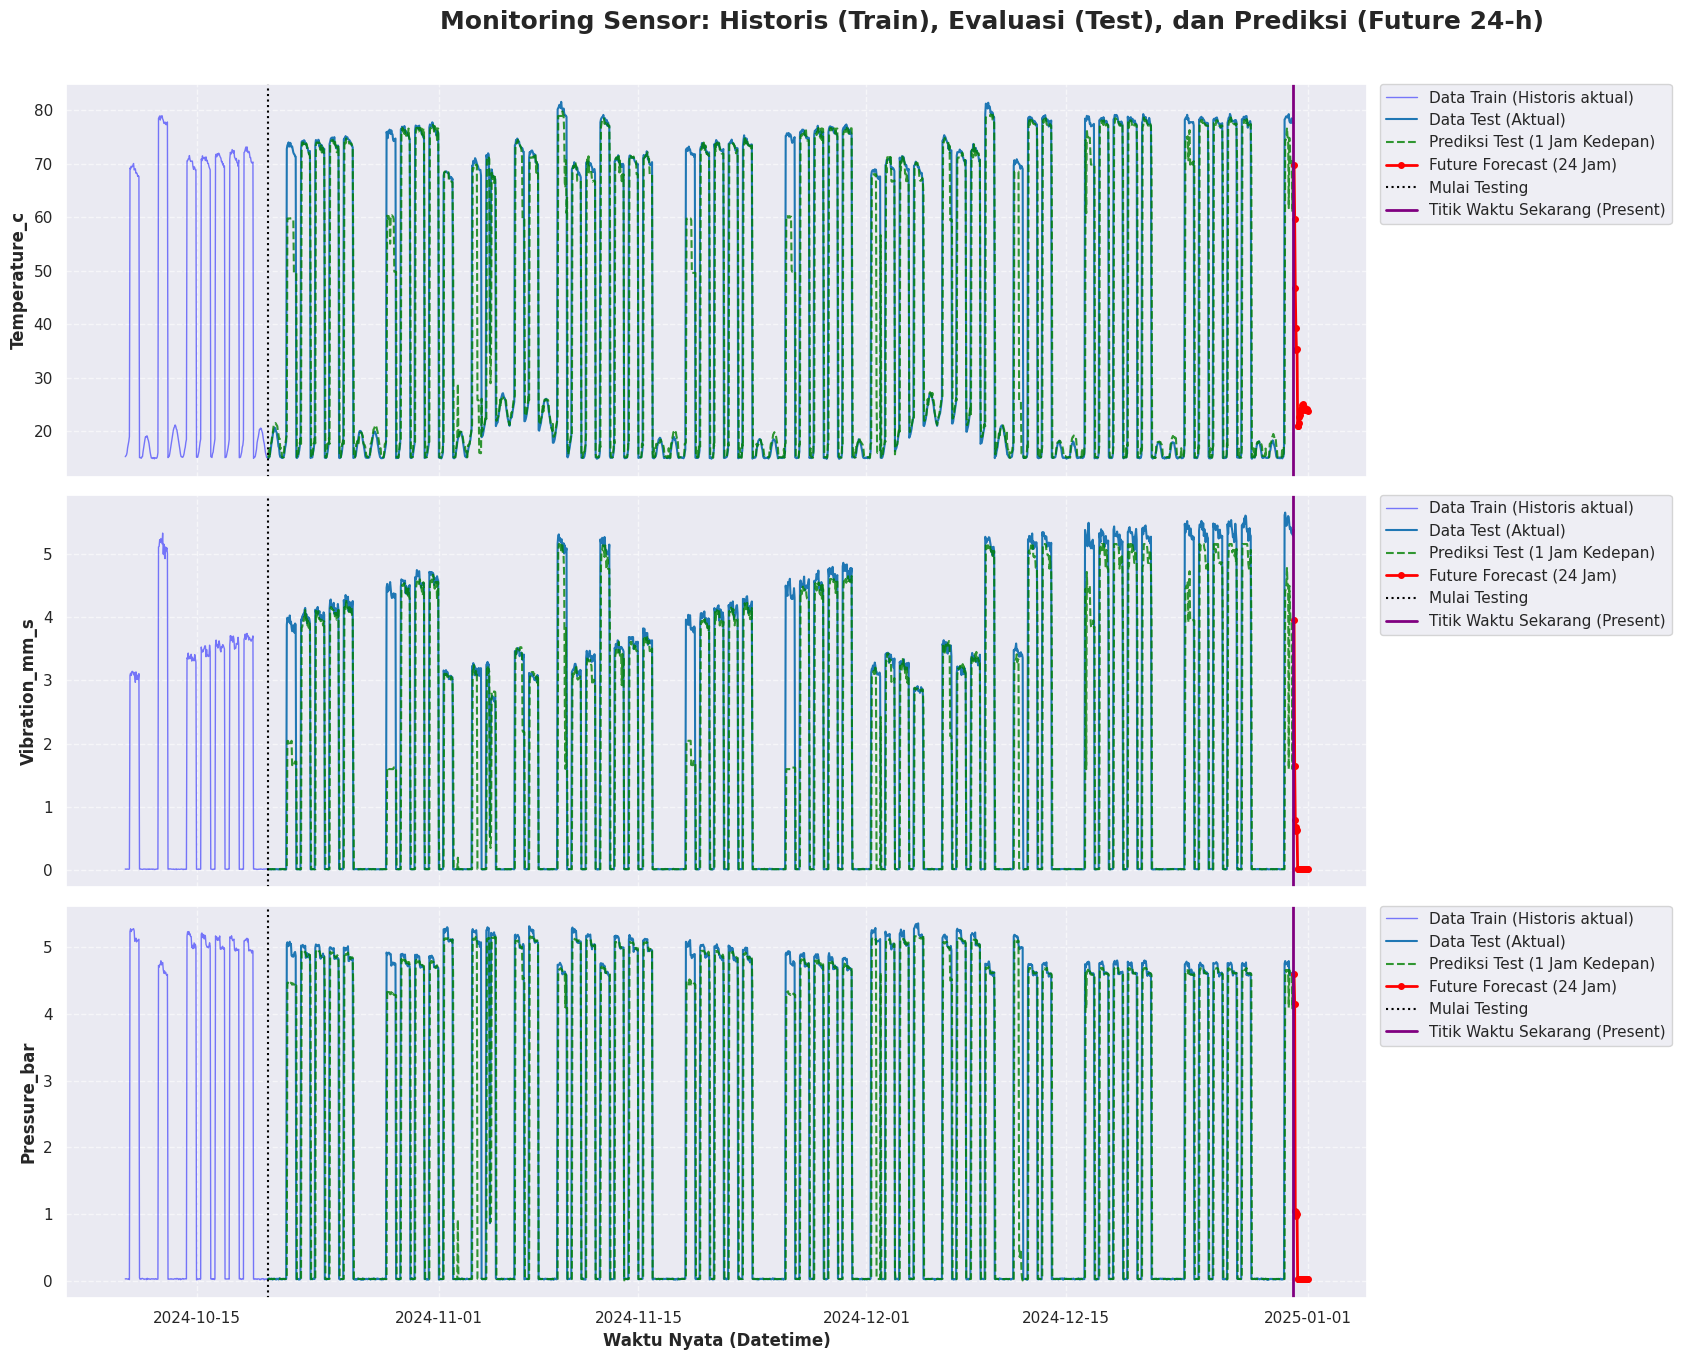

In [77]:
fig, axes = plt.subplots(3, 1, figsize=(20, 14), sharex=True)
fig.suptitle('Monitoring Sensor: Historis (Train), Evaluasi (Test), dan Prediksi (Future 24-h)', 
             fontsize=18, fontweight='bold', y=0.97)

# Tampilkan 10 hari terakhir dari data Train agar grafik tidak terlalu padat
train_display_window = 24 * 10 
plot_time_train = time_train.iloc[-train_display_window:]

for i, col in enumerate(sensors):
    ax = axes[i]
    
    plot_data_train = time_series_df.loc[X_train.index, col].iloc[-train_display_window:]
    ax.plot(plot_time_train, plot_data_train, label='Data Train (Historis aktual)', color='blue', alpha=0.5, linewidth=1)
    
    # B. Plot Data Uji Aktual (Test) - AMBIL DARI df UTAMA
    plot_data_test = time_series_df.loc[X_test.index, col]
    ax.plot(time_test, plot_data_test, label='Data Test (Aktual)', color='#1f77b4', linewidth=1.5)
    
    # C. Plot Prediksi saat Pengujian (Prediksi t+1)
    # Ini menunjukkan seberapa baik model mengikuti data saat ditest
    ax.plot(time_test, Y_pred_df[f'{col}_t_1'], label='Prediksi Test (1 Jam Kedepan)', color='green', linestyle='--', linewidth=1.5, alpha=0.8)
    
    # D. Plot Prediksi MASA DEPAN (24 Horizon dari titik terakhir)
    future_vals = [future_pred_df.iloc[0][f'{col}_t_{h}'] for h in range(1, HORIZON + 1)]
    ax.plot(time_future, future_vals, label='Future Forecast (24 Jam)', color='red', marker='o', markersize=4, linestyle='-', linewidth=2)
    
    # Garis vertikal penanda
    ax.axvline(x=time_test.iloc[0], color='black', linestyle=':', linewidth=1.5, label='Mulai Testing')
    ax.axvline(x=last_time, color='purple', linestyle='-', linewidth=2, label='Titik Waktu Sekarang (Present)')
    
    # Kosmetik Grafik
    ax.set_ylabel(f'{col.capitalize()}', fontweight='bold', fontsize=12)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0.)
    ax.grid(True, linestyle='--', alpha=0.6)

# Format Sumbu X
axes[2].set_xlabel('Waktu Nyata (Datetime)', fontweight='bold', fontsize=12)

plt.xticks(rotation=0) 
plt.tight_layout(rect=[0, 0, 0.85, 0.96]) 
plt.show()

In [78]:
future_pred_array = chain_model.predict(last_X_test)
future_pred_array, future_pred_array.shape

(array([[6.98368378e+01, 3.95939207e+00, 4.59564209e+00, 5.96679840e+01,
         1.64827645e+00, 4.15744972e+00, 4.67055740e+01, 7.89321065e-01,
         1.05228925e+00, 3.93483391e+01, 6.25189364e-01, 1.02878106e+00,
         3.51734962e+01, 6.85170889e-01, 9.75806475e-01, 3.52504234e+01,
         6.34692430e-01, 9.94036376e-01, 2.08921928e+01, 1.53030660e-02,
         2.49186065e-02, 2.09581680e+01, 1.53383734e-02, 2.50257589e-02,
         2.14150810e+01, 1.51646147e-02, 2.52518412e-02, 2.26259899e+01,
         1.52220428e-02, 2.50058025e-02, 2.30458126e+01, 1.52061097e-02,
         2.54252665e-02, 2.37580471e+01, 1.52110644e-02, 2.50124186e-02,
         2.40927906e+01, 1.51769975e-02, 2.48027593e-02, 2.42736683e+01,
         1.52322873e-02, 2.50218436e-02, 2.48518772e+01, 1.52063174e-02,
         2.50084251e-02, 2.50073433e+01, 1.51447915e-02, 2.50465814e-02,
         2.44930077e+01, 1.51914554e-02, 2.51386687e-02, 2.43161983e+01,
         1.52278384e-02, 2.50485204e-02, 2.41483631

In [79]:
time_future, time_future.shape

(DatetimeIndex(['2024-12-31 00:00:00', '2024-12-31 01:00:00',
                '2024-12-31 02:00:00', '2024-12-31 03:00:00',
                '2024-12-31 04:00:00', '2024-12-31 05:00:00',
                '2024-12-31 06:00:00', '2024-12-31 07:00:00',
                '2024-12-31 08:00:00', '2024-12-31 09:00:00',
                '2024-12-31 10:00:00', '2024-12-31 11:00:00',
                '2024-12-31 12:00:00', '2024-12-31 13:00:00',
                '2024-12-31 14:00:00', '2024-12-31 15:00:00',
                '2024-12-31 16:00:00', '2024-12-31 17:00:00',
                '2024-12-31 18:00:00', '2024-12-31 19:00:00',
                '2024-12-31 20:00:00', '2024-12-31 21:00:00',
                '2024-12-31 22:00:00', '2024-12-31 23:00:00'],
               dtype='datetime64[ns]', freq='h'),
 (24,))

In [80]:
future_pred_df, future_pred_df.shape

(   temperature_C_t_1  vibration_mm_s_t_1  pressure_bar_t_1  temperature_C_t_2  \
 0          69.836838            3.959392          4.595642          59.667984   
 
    vibration_mm_s_t_2  pressure_bar_t_2  temperature_C_t_3  \
 0            1.648276           4.15745          46.705574   
 
    vibration_mm_s_t_3  pressure_bar_t_3  temperature_C_t_4  ...  \
 0            0.789321          1.052289          39.348339  ...   
 
    pressure_bar_t_21  temperature_C_t_22  vibration_mm_s_t_22  \
 0           0.025041           24.098366             0.014944   
 
    pressure_bar_t_22  temperature_C_t_23  vibration_mm_s_t_23  \
 0           0.025058           23.895908             0.015021   
 
    pressure_bar_t_23  temperature_C_t_24  vibration_mm_s_t_24  \
 0           0.024849            23.74029             0.015103   
 
    pressure_bar_t_24  
 0           0.028975  
 
 [1 rows x 72 columns],
 (1, 72))

In [81]:
future_pred_df = future_pred_df.T
future_pred_df

,0
temperature_C_t_1,69.836838
vibration_mm_s_t_1,3.959392
pressure_bar_t_1,4.595642
temperature_C_t_2,59.667984
vibration_mm_s_t_2,1.648276
...,...
vibration_mm_s_t_23,0.015021
pressure_bar_t_23,0.024849
temperature_C_t_24,23.740290
vibration_mm_s_t_24,0.015103


In [86]:
future_clean = {
    'temperature_pred': [],
    'vibration_pred': [],
    'pressure_bar_pred': []
}

for i in range(future_pred_df.shape[0]):
    if i % 3 == 0:
        future_clean['temperature_pred'].append(float(future_pred_df.iloc[i].values[0]))
    elif i % 3 == 1:
        future_clean['vibration_pred'].append(float(future_pred_df.iloc[i].values[0]))
    else:
        future_clean['pressure_bar_pred'].append(float(future_pred_df.iloc[i].values[0]))

future_pred_clean_df = pd.DataFrame(future_clean, index=time_future)
future_pred_clean_df

,temperature_pred,vibration_pred,pressure_bar_pred
2024-12-31 00:00:00,69.836838,3.959392,4.595642
2024-12-31 01:00:00,59.667984,1.648276,4.157450
2024-12-31 02:00:00,46.705574,0.789321,1.052289
2024-12-31 03:00:00,39.348339,0.625189,1.028781
2024-12-31 04:00:00,35.173496,0.685171,0.975806
2024-12-31 05:00:00,35.250423,0.634692,0.994036
2024-12-31 06:00:00,20.892193,0.015303,0.024919
2024-12-31 07:00:00,20.958168,0.015338,0.025026
2024-12-31 08:00:00,21.415081,0.015165,0.025252
2024-12-31 09:00:00,22.625990,0.015222,0.025006


In [228]:
df_by_status_1.describe()

,temperature_C,vibration_mm_s,pressure_bar,status
count,4578.000000,4578.000000,4578.000000,4578.0
mean,19.783940,0.024442,0.041867,1.0
std,4.311554,0.114191,0.187836,0.0
min,14.773333,0.007000,0.010000,1.0
25%,16.035625,0.013417,0.021667,1.0
50%,19.400417,0.015083,0.025000,1.0
75%,22.449792,0.016833,0.027500,1.0
max,82.308333,4.171333,4.984167,1.0


In [227]:
df_by_status_0.describe()

,temperature_C,vibration_mm_s,pressure_bar,status
count,4134.000000,4134.000000,4134.000000,4134.0
mean,74.100672,3.978320,4.965488,0.0
std,4.114061,0.822573,0.212716,0.0
min,65.445000,2.667417,4.560000,0.0
25%,70.672083,3.234875,4.773333,0.0
50%,73.972083,3.898250,4.982500,0.0
75%,77.722500,4.645229,5.135833,0.0
max,83.317500,5.680333,5.385833,0.0


In [247]:
def status_downtime(row):
    # Percentil bawah
    lowerbound_temp = np.percentile(df_by_status_0['temperature_C'], 25)
    lowerbound_vibration = np.percentile(df_by_status_0['vibration_mm_s'], 25)
    lowerbound_pressure_bar = np.percentile(df_by_status_0['pressure_bar'], 25)
    
    # Percentil atas
    upperbound_temp = np.percentile(df_by_status_0['temperature_C'], 75)
    upperbound_vibration = np.percentile(df_by_status_0['vibration_mm_s'], 75)
    upperbound_pressure_bar = np.percentile(df_by_status_0['pressure_bar'], 75)
    
    temp_result = lowerbound_temp <= row['temperature_pred'] <= upperbound_temp
    vibration_result = lowerbound_vibration <= row['vibration_pred'] <= upperbound_vibration
    pressure_bar_result = lowerbound_pressure_bar <= row['pressure_bar_pred'] <= upperbound_pressure_bar
    if temp_result and vibration_result and pressure_bar_result:
        return 'normal'
    return 'downtime'

future_pred_clean['status'] = future_pred_clean.apply(status_downtime, axis=1)
future_pred_clean

,temperature_pred,vibration_pred,pressure_bar_pred,status
2024-12-29 00:00:00,14.831567,0.014885,0.025226,downtime
2024-12-29 01:00:00,15.908458,0.014880,0.024853,downtime
2024-12-29 02:00:00,17.315489,0.015528,0.024787,downtime
2024-12-29 03:00:00,17.176163,0.015127,0.025175,downtime
2024-12-29 04:00:00,17.305641,0.015376,0.024702,downtime
2024-12-29 05:00:00,17.454332,0.015263,0.024946,downtime
2024-12-29 06:00:00,20.316032,0.015279,0.025077,downtime
2024-12-29 07:00:00,20.134176,0.015340,0.025096,downtime
2024-12-29 08:00:00,20.444599,0.015270,0.025034,downtime
2024-12-29 09:00:00,20.771059,0.015191,0.025012,downtime


In [205]:
eval_results = []
eval_temp_mean = []
eval_vibration_mean = []
eval_press_bar_mean = []

# Evaluasi performa untuk masing-masing horizon waktu
for i, target_name in enumerate(targets):
    mae = mean_absolute_error(Y_test[target_name], Y_pred_df[target_name])
    
    # Memasukkan hasil ke dalam dictionary
    eval_results.append({
        'Target Name': target_name,
        'Horizon (Jam ke-)': i + 1,
        'MAE': round(mae, 4) 
    })
    if target_name.startswith('temperature'):
        eval_temp_mean.append(mae)
    elif target_name.startswith('vibration'):
        eval_vibration_mean.append(mae)
    elif target_name.startswith('pressure_bar'):
        eval_press_bar_mean.append(mae)

df_evaluation = pd.DataFrame(eval_results)
df_evaluation

,Target Name,Horizon (Jam ke-),MAE
0,temperature_C_t_1,1,7.5200
1,vibration_mm_s_t_1,2,0.5767
2,pressure_bar_t_1,3,0.6525
3,temperature_C_t_2,4,10.8169
4,vibration_mm_s_t_2,5,0.8090
...,...,...,...
67,vibration_mm_s_t_23,68,1.9622
68,pressure_bar_t_23,69,2.2583
69,temperature_C_t_24,70,25.1034
70,vibration_mm_s_t_24,71,1.9877


In [206]:
pd.DataFrame({
    'Sensor': ['Temperature', 'Vibration', 'Pressure'],
    'MAE Mean': [np.mean(eval_temp_mean), np.mean(eval_vibration_mean), np.mean(eval_press_bar_mean)]
})

,Sensor,MAE Mean
0,Temperature,23.929459
1,Vibration,1.767904
2,Pressure,2.044194


In [288]:
model_filename = 'xgboost_chain_model_24h.joblib'
joblib.dump(chain_model, model_filename)

['xgboost_chain_model_24h.joblib']